# Lung Disease (COPD) Prediction and Analysis

## Project Overview
This project develops a robust, interpretable, and clinically actionable machine learning pipeline for predicting **Chronic Obstructive Pulmonary Disease (COPD)** — emphysema and chronic bronchitis — from demographic, tobacco-exposure, symptom and routine blood-test data. It follows the same end-to-end workflow as the kidney (CKD) notebook and adds a benchmark of modern tabular models.

**Dataset:** `COPD_NHANES.csv`, built from six public CDC NHANES survey cycles (2007–2020): **24,522 examined adults aged 40+**, 25 columns, **9.9 % COPD prevalence**. The data dictionary is in `data/README.md` and `data/build_copd_nhanes.py` rebuilds the file from the CDC servers.

## Key Highlights
* **Leakage-aware preprocessing:** survey skip-patterns are resolved at build time (a never-smoker has 0 pack-years, not a missing value), features are scaled *before* KNN imputation so no single unit dominates the neighbour search, SMOTENC keeps synthetic patients' categorical answers valid, and every fitted step lives inside the cross-validation pipeline.
* **Clinical feature engineering:** pack-years, log-cotinine, neutrophil-to-lymphocyte ratio (NLR) and a comorbidity count.
* **17 classifiers:** the 9 kidney-notebook baselines plus 8 modern models — CatBoost, Explainable Boosting Machine, TabNet, FT-Transformer, RealMLP, TabM, TabPFN and a Stacking Ensemble.
* **Honest model selection:** hyper-parameters (including *whether to oversample at all*) are tuned on cross-validated PR-AUC; the test set is used only for reporting; the one-standard-error rule prefers the simplest model when the difference is within noise.
* **Calibration & clinical thresholding:** isotonic calibration and a cost-based threshold (a missed COPD case costs 5× a false alarm) chosen on out-of-fold *training* predictions, with bootstrapped 95 % confidence intervals.
* **Unsupervised learning, anomaly detection and an explainable two-stage cascade** with SHAP explanations, as in the kidney notebook.

# Import Libraries

In [1]:
import os
import sys
import time
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline # Kept for standard preprocessing
from imblearn.pipeline import Pipeline as ImbPipeline # Required for SMOTE integration
from imblearn.over_sampling import SMOTENC # SMOTE for mixed numeric + categorical data

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, precision_score, recall_score,
    f1_score, precision_recall_curve, roc_curve, auc, average_precision_score, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier # Advanced Gradient Boosting
from lightgbm import LGBMClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

import torch

import joblib

RANDOM_STATE = 42
import psutil
available_gb = psutil.virtual_memory().available / 1024**3
# Each parallel worker holds ~0.7 GB of RAM; keep ~2.5 GB for this kernel and the OS.
# The N_JOBS environment variable overrides the estimate (e.g. N_JOBS=3 when RAM is shared with other programs)
N_JOBS = int(os.environ.get('N_JOBS') or max(1, min(8, (os.cpu_count() or 2) - 2, (available_gb - 2.5) // 0.7)))


def keep_workers_light():
    # scikit-learn copies the warning filters into every parallel worker. torch and lightning register
    # filters for their own warning classes, so each worker would import torch + CUDA (~1.5 GB of RAM each).
    # Keep only the light libraries' filters before any parallel work.
    light_libraries = ("builtins", "warnings", "numpy", "scipy", "pandas", "sklearn")
    warnings.filters[:] = [f for f in warnings.filters if f[2].__module__.split(".")[0] in light_libraries]

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'     # GPU for the deep tabular models
print(f"CPU workers: {N_JOBS} (RAM available: {available_gb:.1f} GB) | Deep-learning device: {DEVICE}")

CPU workers: 3 (RAM available: 4.4 GB) | Deep-learning device: cuda


# Database Load & Analysis

In [2]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    project_dir = "/content/drive/MyDrive/AI Projects/Lung Disease/"
else:
    project_dir = os.path.abspath("..")          # models/lung/tabular/ — this notebook lives in notebooks/

data_folder = os.path.join(project_dir, "data")
images_dir = os.path.join(project_dir, "images")
results_dir = os.path.join(project_dir, "results")
models_dir = os.path.join(project_dir, "models")
for folder in (images_dir, results_dir, models_dir):
    os.makedirs(folder, exist_ok=True)

def save_figure(filename):
    # Keep a copy of the key plots in images/ for the README
    plt.savefig(os.path.join(images_dir, filename), dpi=110, bbox_inches='tight')

In [3]:
csv_filename = "COPD_NHANES.csv"

if os.path.exists(data_folder):
    print(f"Files located in '{data_folder}':")
    print(os.listdir(data_folder))
    print("=" * 60)
else:
    print(f"⚠️ Directory not found: {data_folder}")

try:
    lung_data = pd.read_csv(os.path.join(data_folder, csv_filename))

    print("\n DATASET PREVIEW (First 5 Rows):")
    display(lung_data.head())

    print("\n DATASET STRUCTURE:")
    lung_data.info()

    print("\n STATISTICAL SUMMARY (Transposed):")
    display(lung_data.describe().T)

except FileNotFoundError:
    print(f"\n❌ ERROR: Could not find '{csv_filename}'.")
    print("Rebuild it from CDC NHANES with: python data/build_copd_nhanes.py (run from models/lung/tabular/)")

Files located in 'E:\Disease-Risk-Prediction\lung\tabular\data':
['build_copd_nhanes.py', 'COPD_NHANES.csv', 'raw', 'README.md']

 DATASET PREVIEW (First 5 Rows):


,participant_id,survey_cycle,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,waist_cm,height_cm,...,asthma_history,heart_failure,coronary_heart_disease,sob_on_exertion,general_health,eosinophils,neutrophils,lymphocytes,hemoglobin,copd_present
0,41475,2007-2008,62.0,Female,Other/Multi-Racial,3.0,1.83,58.04,156.3,154.7,...,Yes,Yes,No,Yes,4.0,0.1,6.3,1.7,14.1,0
1,41477,2007-2008,71.0,Male,Non-Hispanic White,3.0,1.50,30.05,109.5,167.1,...,No,No,No,No,3.0,1.0,4.6,3.2,16.2,0
2,41479,2007-2008,52.0,Male,Mexican American,1.0,2.20,27.56,95.4,154.4,...,No,No,No,No,3.0,0.1,2.3,2.4,15.6,0
3,41482,2007-2008,64.0,Male,Mexican American,2.0,4.01,33.64,117.0,173.8,...,No,No,No,Yes,4.0,0.1,6.6,2.1,15.6,0
4,41483,2007-2008,66.0,Male,Non-Hispanic Black,4.0,1.14,44.06,145.6,173.8,...,No,No,No,No,4.0,0.5,6.1,2.4,12.4,0



 DATASET STRUCTURE:
<class 'pandas.DataFrame'>
RangeIndex: 24522 entries, 0 to 24521
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   participant_id          24522 non-null  int64  
 1   survey_cycle            24522 non-null  str    
 2   age                     24522 non-null  float64
 3   gender                  24522 non-null  str    
 4   ethnicity               24522 non-null  str    
 5   education_level         24484 non-null  float64
 6   poverty_income_ratio    21893 non-null  float64
 7   bmi                     24072 non-null  float64
 8   waist_cm                22894 non-null  float64
 9   height_cm               24130 non-null  float64
 10  smoking_status          24501 non-null  str    
 11  cigarettes_per_day      24201 non-null  float64
 12  smoking_years           24292 non-null  float64
 13  household_smokers       23969 non-null  float64
 14  serum_cotinine          2307

,count,mean,std,min,25%,50%,75%,max
participant_id,24522.0,79188.758503,25313.234862,41475.000,57678.000,76235.500,93126.25000,124822.00
age,24522.0,59.817755,12.191093,40.000,49.000,60.000,70.00000,80.00
education_level,24484.0,3.333606,1.312801,1.000,2.000,4.000,4.00000,5.00
poverty_income_ratio,21893.0,2.591156,1.630582,0.000,1.160,2.180,4.25000,5.00
bmi,24072.0,29.618521,6.838221,13.180,25.000,28.570,33.00000,84.87
waist_cm,22894.0,101.682467,15.603398,56.200,91.000,100.400,110.80000,187.50
height_cm,24130.0,166.129443,10.166634,123.300,158.700,165.800,173.40000,203.80
cigarettes_per_day,24201.0,7.042804,12.302030,0.000,0.000,0.000,10.00000,95.00
smoking_years,24292.0,13.147938,17.653935,0.000,0.000,0.000,27.00000,72.00
household_smokers,23969.0,0.294422,0.600166,0.000,0.000,0.000,0.00000,2.00


### Dataset Distribution

In [4]:
print(lung_data['copd_present'].value_counts(dropna=False))
print(f"\nCOPD prevalence: {lung_data['copd_present'].mean():.2%}")
lung_data = lung_data.dropna(subset=['copd_present'])   # Remove rows without a label (none expected)

copd_present
0    22092
1     2430
Name: count, dtype: int64

COPD prevalence: 9.91%


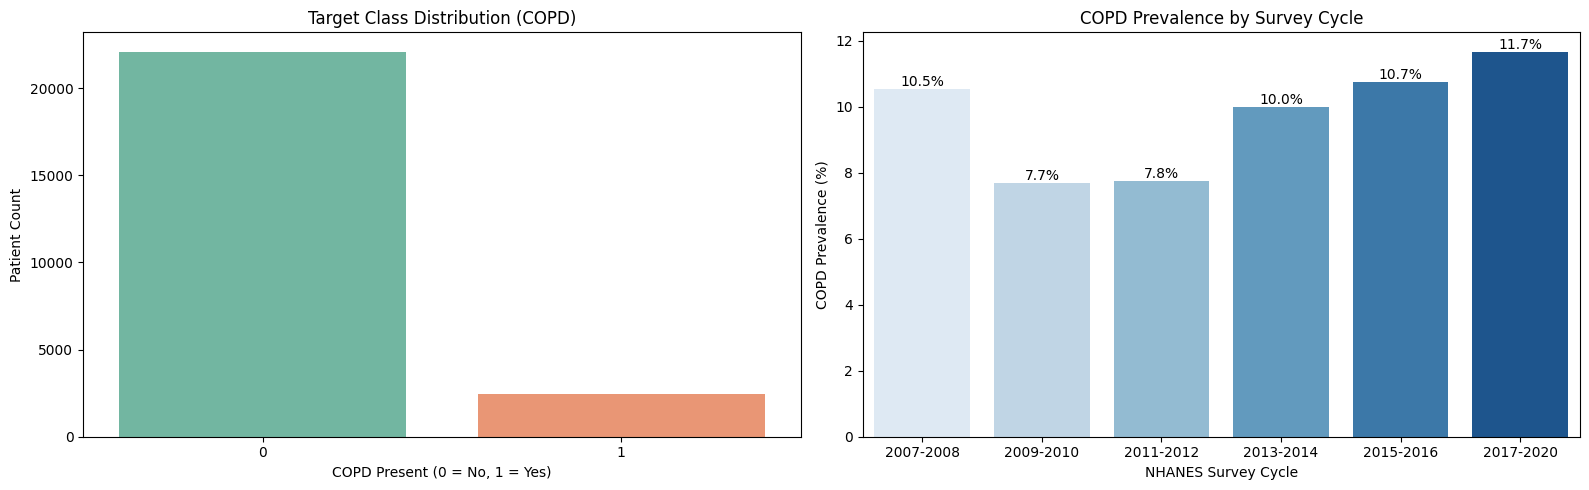

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(x="copd_present", data=lung_data, palette="Set2", ax=axes[0])
axes[0].set_xlabel("COPD Present (0 = No, 1 = Yes)")
axes[0].set_ylabel("Patient Count")
axes[0].set_title("Target Class Distribution (COPD)")

# Label-drift check: 2017-2020 asked one combined question instead of separate ones
cycle_prevalence = lung_data.groupby('survey_cycle')['copd_present'].mean() * 100
sns.barplot(x=cycle_prevalence.index, y=cycle_prevalence.values, palette="Blues", ax=axes[1])
for container in axes[1].containers:          # seaborn draws one container per bar
    axes[1].bar_label(container, fmt='%.1f%%')
axes[1].set_xlabel("NHANES Survey Cycle")
axes[1].set_ylabel("COPD Prevalence (%)")
axes[1].set_title("COPD Prevalence by Survey Cycle")

plt.tight_layout()
save_figure("target_distribution.png")
plt.show()

* **Imbalance:** 22,092 adults without COPD and 2,430 with it (**9.9 %**), about 9 : 1. Accuracy is therefore a useless headline metric: answering "No COPD" for everyone scores 90 %. Models are tuned and compared on **PR-AUC**.
* **Prevalence by cycle:** 10.5 % → 7.7 % → 7.8 % → 10.0 % → 10.7 % → **11.7 %** (2017–2020). The rise in the last cycle matches the questionnaire change (one combined COPD / emphysema / chronic bronchitis question instead of three), so part of it is *label drift*, not more disease. `survey_cycle` is dropped as a feature below, so the model cannot learn "later cycle = higher risk".

### Missing Values & Survey Skip-Patterns
NHANES skips questions that do not apply — a never-smoker is never asked how many cigarettes they smoke per day. Left as blanks, a KNN imputer would *invent* a smoking history for them. The build script already converted those structural gaps into true zeros (and refused / don't-know codes into NaN), so every blank left in the table is a genuine unknown. The checks below verify that before any modelling.

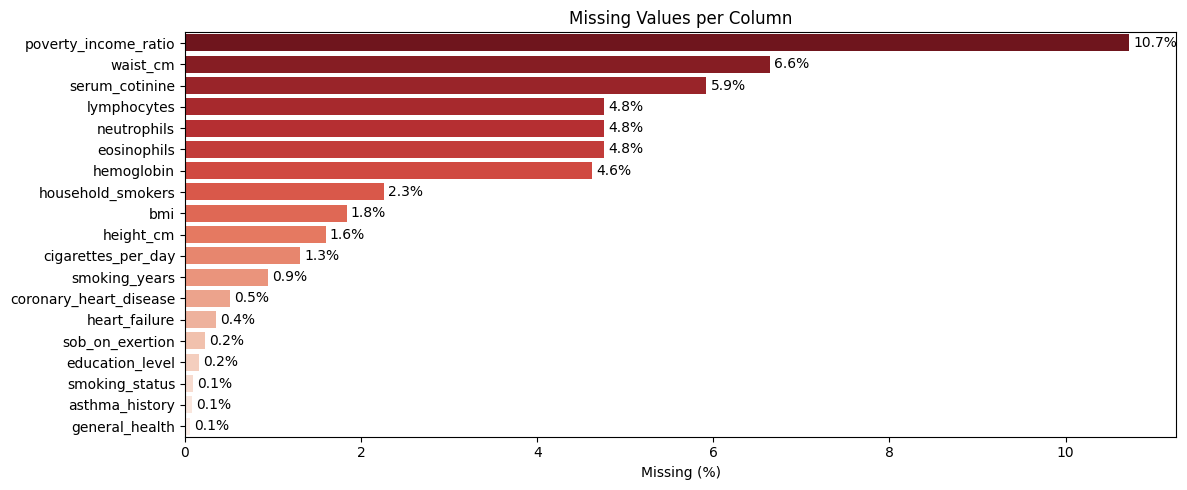

Never-smokers: 12,931
  with non-zero cigarettes/day : 0
  with non-zero smoking years  : 0
Rows where smoking years exceed age: 0

Median serum cotinine (ng/mL) by smoking status — the biomarker agrees with the questionnaire:
smoking_status
Current    236.000
Former       0.027
Never        0.019

COPD prevalence by smoking status:
smoking_status
Current    18.6 %
Former     13.3 %
Never       5.1 %


In [6]:
missing = (lung_data.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=missing.values, y=missing.index, palette="Reds_r")
for container in ax.containers:               # seaborn draws one container per bar
    ax.bar_label(container, fmt='%.1f%%', padding=3)
plt.xlabel("Missing (%)")
plt.ylabel("")
plt.title("Missing Values per Column")
plt.tight_layout()
save_figure("missing_values.png")
plt.show()

never = lung_data[lung_data['smoking_status'] == 'Never']
print(f"Never-smokers: {len(never):,}")
print(f"  with non-zero cigarettes/day : {(never['cigarettes_per_day'] != 0).sum()}")
print(f"  with non-zero smoking years  : {(never['smoking_years'] != 0).sum()}")
print(f"Rows where smoking years exceed age: {(lung_data['smoking_years'] > lung_data['age']).sum()}")

print("\nMedian serum cotinine (ng/mL) by smoking status — the biomarker agrees with the questionnaire:")
print(lung_data.groupby('smoking_status')['serum_cotinine'].median().round(3).to_string())

print("\nCOPD prevalence by smoking status:")
print((lung_data.groupby('smoking_status')['copd_present'].mean() * 100).round(1).astype(str).add(' %').to_string())

### Correlation Analysis

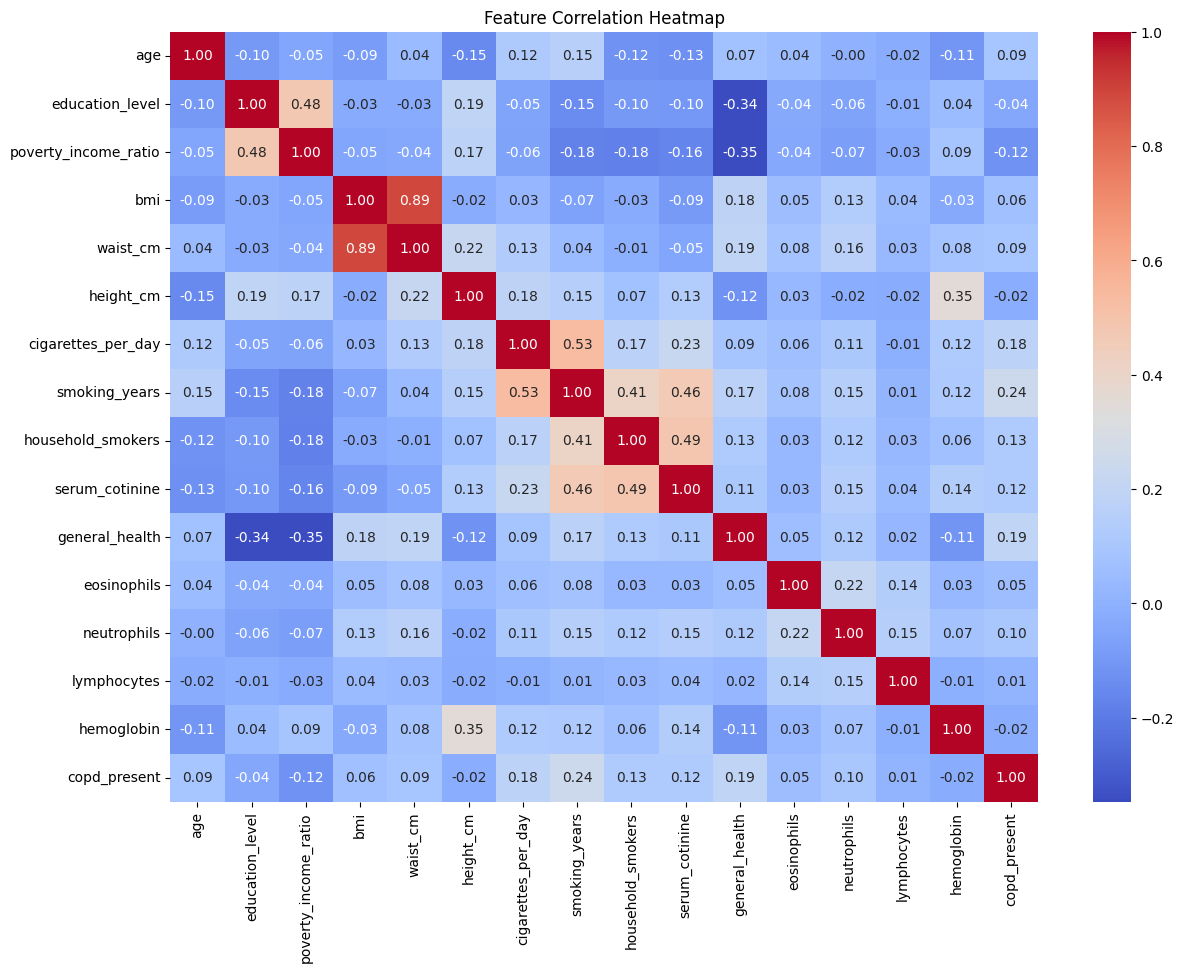

In [7]:
# Drop the identifier and survey metadata — they describe the survey, not the patient
lung_data = lung_data.drop(columns=['participant_id', 'survey_cycle'], errors='ignore')

plt.figure(figsize=(14, 10))
sns.heatmap(lung_data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
save_figure("correlation_heatmap.png")
plt.show()

* **One redundant pair:** `waist_cm` and `bmi` correlate at **r = 0.89**, so waist circumference is dropped in the next cell.
* **A tobacco cluster:** cigarettes/day ↔ smoking years (0.53), household smokers ↔ cotinine (0.49), smoking years ↔ cotinine (0.46). These are different views of the same exposure, which is why they are combined into pack-years and log-cotinine.
* **Weak single-feature signal:** no feature correlates with `copd_present` above **0.24** (smoking years). General health 0.19, cigarettes/day 0.18, household smokers 0.13, cotinine 0.12 and poverty ratio −0.12 follow. COPD risk is spread across many modest factors, so expect a modest ceiling on how well any model can rank patients.
* The skip-pattern checks above pass: no never-smoker has a non-zero smoking dose, and median cotinine (Current 236 ng/mL vs Former 0.027 / Never 0.019) agrees with the questionnaire. COPD prevalence is 18.6 % in current, 13.3 % in former and 5.1 % in never-smokers.

In [8]:
threshold = 0.85
target = 'copd_present'

# Inputs of the feature-engineering step must survive the redundancy filter
engineering_inputs = ['cigarettes_per_day', 'smoking_years', 'serum_cotinine', 'neutrophils', 'lymphocytes']

# The target is excluded: a feature that tracks the label is signal, not redundancy
corr_matrix = lung_data.drop(columns=[target]).corr(numeric_only=True).abs()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

features_to_drop = [column for column in upper_triangle.columns
                    if any(upper_triangle[column] > threshold) and column not in engineering_inputs]

print(f"Features highly correlated (>{threshold}) will be dropped: {features_to_drop}")
for column in features_to_drop:
    print(f"  {column} ~ {upper_triangle[column].idxmax()}: r = {upper_triangle[column].max():.3f}")

lung_data = lung_data.drop(columns=features_to_drop)
print("\nRemaining columns in the dataset:")
print(lung_data.columns.tolist())

Features highly correlated (>0.85) will be dropped: ['waist_cm']
  waist_cm ~ bmi: r = 0.894

Remaining columns in the dataset:
['age', 'gender', 'ethnicity', 'education_level', 'poverty_income_ratio', 'bmi', 'height_cm', 'smoking_status', 'cigarettes_per_day', 'smoking_years', 'household_smokers', 'serum_cotinine', 'asthma_history', 'heart_failure', 'coronary_heart_disease', 'sob_on_exertion', 'general_health', 'eosinophils', 'neutrophils', 'lymphocytes', 'hemoglobin', 'copd_present']


# Dataset Pre-processing

### Feature Engineering
Four clinically motivated features. The function is row-wise and stateless (it learns nothing from the data), so it is safe to run on any split; inside the model it runs as the first pipeline step.

| Feature | Formula | Why |
|---|---|---|
| `pack_years` | cigarettes/day × years smoked ÷ 20 | The standard cumulative tobacco dose; the main COPD risk factor. 0 for never-smokers. |
| `log_cotinine` | log10(serum cotinine) | Cotinine spans five orders of magnitude (0.011 to >1,000 ng/mL). The log replaces the raw value, which would otherwise swamp distance- and gradient-based models. |
| `nlr` | neutrophils ÷ lymphocytes | Neutrophil-to-lymphocyte ratio, a marker of the systemic inflammation seen in COPD. |
| `comorbidity_count` | asthma + heart failure + coronary heart disease | Cardiopulmonary burden in one ordinal number. |

In [9]:
def add_custom_features(X_df):
    X_new = X_df.copy()

    # Cumulative tobacco dose: 1 pack-year = 20 cigarettes/day for one year (0 for never-smokers)
    X_new['pack_years'] = X_new['cigarettes_per_day'] * X_new['smoking_years'] / 20

    # Log scale for cotinine; clipped at the assay's reporting floor so the log is always defined
    X_new['log_cotinine'] = np.log10(X_new['serum_cotinine'].clip(lower=0.01))

    # Neutrophil-to-lymphocyte ratio (lymphocytes floored to avoid division by ~0)
    X_new['nlr'] = X_new['neutrophils'] / X_new['lymphocytes'].clip(lower=0.1)

    # Number of cardiopulmonary comorbidities; unknown only if all three answers are unknown
    comorbidities = ['asthma_history', 'heart_failure', 'coronary_heart_disease']
    answered = X_new[comorbidities].notna().any(axis=1)
    X_new['comorbidity_count'] = (X_new[comorbidities] == 'Yes').sum(axis=1).where(answered)

    return X_new

feature_engineering = FunctionTransformer(add_custom_features)

# Sanity check on the full table (the pipeline recomputes this inside every CV fold)
engineered_preview = add_custom_features(lung_data)
print(engineered_preview.groupby('smoking_status')[['pack_years', 'log_cotinine', 'nlr']].median().round(2))
never_pack_years = engineered_preview.loc[engineered_preview['smoking_status'] == 'Never', 'pack_years'].unique()
print(f"\nPack-years of never-smokers (must be exactly 0): {never_pack_years}")

                pack_years  log_cotinine   nlr
smoking_status                                
Current               17.1          2.37  2.00
Former                12.0         -1.57  2.08
Never                  0.0         -1.72  1.92

Pack-years of never-smokers (must be exactly 0): [0.]


### Preprocessing
The pipeline order matters, and differs from the kidney notebook in three deliberate ways:

1. **Scale → impute** (not impute → scale). `KNNImputer` finds neighbours by Euclidean distance; on raw units, poverty ratio (0–5) would count for nothing next to height in cm. `RobustScaler` ignores NaNs while fitting, so it can run first.
2. **SMOTENC instead of SMOTE, before one-hot encoding.** Plain SMOTE after one-hot encoding interpolates the dummy columns and creates patients who are "0.4 current smoker". SMOTENC interpolates only the numeric features and copies categorical answers from real neighbours.
3. **Oversampling is optional.** `'smote'` is a pipeline step that the grid search may switch off (`'passthrough'`).

The train/test split happens before anything is fitted, and all fitted steps (scaler, imputer, SMOTENC, encoder) live inside the pipeline, so they are re-fitted on each CV training fold only.

In [10]:
X = lung_data.drop(columns=['copd_present'])
y = lung_data['copd_present']   # Already 0 and 1

categorical_features = X.select_dtypes(exclude='number').columns.tolist()
numerical_existing_features = X.select_dtypes(include='number').columns.tolist()

# Engineered features join the numeric block; the log replaces raw cotinine
engineered_features = ['pack_years', 'log_cotinine', 'nlr', 'comorbidity_count']
numerical_features = [c for c in numerical_existing_features if c != 'serum_cotinine'] + engineered_features

numeric_sub_pipeline = Pipeline(steps=[
    ('scaler', RobustScaler()),                 # Scale first so every feature counts equally in KNN distances
    ('imputer', KNNImputer(n_neighbors=5))      # Impute missing clinical values from the 5 most similar patients
])

imputation = ColumnTransformer(
    transformers=[
        ('num_transform', numeric_sub_pipeline, numerical_features),
        ('cat_transform', SimpleImputer(strategy='most_frequent'), categorical_features)
    ],
    verbose_feature_names_out=False
).set_output(transform='pandas')                # keep column names so SMOTENC can find the categoricals

encoding = ColumnTransformer(
    transformers=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)],
    remainder='passthrough',                    # numeric block is already scaled + imputed
    verbose_feature_names_out=False
)

# Interpolates numeric features, copies categories from real neighbours
smote = SMOTENC(categorical_features=categorical_features, random_state=RANDOM_STATE)

def build_pipeline(classifier, oversample=True):
    # feature engineering -> scale + impute -> (SMOTENC) -> one-hot -> classifier
    return ImbPipeline(steps=[
        ('engineering', clone(feature_engineering)),
        ('imputation', clone(imputation)),
        ('smote', clone(smote) if oversample else 'passthrough'),
        ('encoding', clone(encoding)),
        ('classifier', classifier)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # Cross-Validation

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nX_train shape: {X_train.shape} | COPD cases: {y_train.sum():,} ({y_train.mean():.1%})")
print(f"X_test shape: {X_test.shape} | COPD cases: {y_test.sum():,} ({y_test.mean():.1%})")
print("Preprocessing pipeline configured successfully with advanced features!")

Numerical features (17): ['age', 'education_level', 'poverty_income_ratio', 'bmi', 'height_cm', 'cigarettes_per_day', 'smoking_years', 'household_smokers', 'general_health', 'eosinophils', 'neutrophils', 'lymphocytes', 'hemoglobin', 'pack_years', 'log_cotinine', 'nlr', 'comorbidity_count']
Categorical features (7): ['gender', 'ethnicity', 'smoking_status', 'asthma_history', 'heart_failure', 'coronary_heart_disease', 'sob_on_exertion']

X_train shape: (19617, 21) | COPD cases: 1,944 (9.9%)
X_test shape: (4905, 21) | COPD cases: 486 (9.9%)
Preprocessing pipeline configured successfully with advanced features!


# Model Training

### Model Training Setup
**Tuning metric: PR-AUC (average precision), not recall.** With 10 % prevalence, recall on its own can be maximised by a model that calls almost everyone sick — a grid search on `scoring='recall'` rewards exactly that. PR-AUC measures how well a model ranks real COPD cases above healthy patients across *all* thresholds, and the clinical recall target is enforced later by the cost-based threshold. For reference, a random model scores PR-AUC ≈ 0.10 (the prevalence).

**Oversampling is tuned, not assumed.** Every grid includes `smote: [SMOTENC, 'passthrough']`, so cross-validation decides per model whether synthetic minority samples help.

The classification report under each model is on the held-out test set at the default 0.5 threshold. Models trained without SMOTE rarely reach 0.5 at 10 % prevalence, so their recall there looks low. The threshold is fixed properly in the *Threshold Analysis* section.

In [11]:
target_classes = ['No COPD', 'COPD Present']
SMOTE_OPTIONS = [smote, 'passthrough']      # oversampling on / off, chosen by cross-validation

fitted_models = {}    # model name -> best pipeline, refit on the full training set
cv_summary = {}       # model name -> cross-validated PR-AUC of the chosen settings

# Resumable runs: every tuned model is cached, so a crash or reboot only costs the model in progress.
# Set the RERUN_GRID=1 environment variable to tune everything again.
GRID_CACHE_DIR = os.path.join(project_dir, 'notebooks', 'grid_cache')
os.makedirs(GRID_CACHE_DIR, exist_ok=True)
RERUN_GRID = os.environ.get('RERUN_GRID', '0') == '1'

def run_grid_search(name, estimator, param_grid, n_jobs=N_JOBS):
    # Tune on 5-fold CV PR-AUC (training data only), then report once on the untouched test set
    cache_file = os.path.join(GRID_CACHE_DIR, ''.join(c if c.isalnum() else '_' for c in name) + '.joblib')
    if os.path.exists(cache_file) and not RERUN_GRID:
        cached = joblib.load(cache_file)
        fitted_models[name], cv_summary[name], best_params = cached['model'], cached['summary'], cached['best_params']
        print(f"(Loaded from {os.path.basename(cache_file)}: tuned in an earlier run of this notebook)")
    else:
        keep_workers_light()    # workers must not import torch (see the first cell)
        start = time.time()
        grid = GridSearchCV(estimator=estimator, param_grid=param_grid, cv=cv_strategy,
                            scoring='average_precision', n_jobs=n_jobs)
        grid.fit(X_train, y_train)
        minutes = (time.time() - start) / 60

        fold_scores = np.array([grid.cv_results_[f'split{k}_test_score'][grid.best_index_]
                                for k in range(cv_strategy.get_n_splits())])
        steps = getattr(grid.best_estimator_, 'named_steps', {})
        smote_used = 'per base model' if 'smote' not in steps else ('on' if steps['smote'] != 'passthrough' else 'off')

        fitted_models[name] = grid.best_estimator_
        cv_summary[name] = {'CV PR-AUC': fold_scores.mean(),
                            'CV SE': fold_scores.std(ddof=1) / np.sqrt(len(fold_scores)),
                            'SMOTE': smote_used, 'Tuning Time (min)': minutes}
        best_params = {k.replace('classifier__', ''): v for k, v in grid.best_params_.items() if k != 'smote'}
        try:
            joblib.dump({'model': fitted_models[name], 'summary': cv_summary[name], 'best_params': best_params}, cache_file)
        except Exception as e:     # caching is a convenience; the run continues without it
            print(f"(Could not cache {name}: {e})")

    print(f"{name} Best CV PR-AUC: {cv_summary[name]['CV PR-AUC']:.4f} (± {cv_summary[name]['CV SE']:.4f} SE) | "
          f"SMOTE: {cv_summary[name]['SMOTE']} | {cv_summary[name]['Tuning Time (min)']:.1f} min")
    print(f"Best params: {best_params}\n")
    print(classification_report(y_test, fitted_models[name].predict(X_test), target_names=target_classes, zero_division=0))
    return fitted_models[name]

### Logistic Regression

In [12]:
lr_pipeline = build_pipeline(LogisticRegression(solver='liblinear', max_iter=2000, random_state=RANDOM_STATE))

lr_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'classifier__l1_ratio': [0.0, 1.0]          # 0 = L2 (ridge), 1 = L1 (lasso)
}
lr_grid = run_grid_search('Logistic Regression', lr_pipeline, lr_param_grid)

(Loaded from Logistic_Regression.joblib: tuned in an earlier run of this notebook)
Logistic Regression Best CV PR-AUC: 0.4608 (± 0.0116 SE) | SMOTE: off | 3.1 min
Best params: {'C': 0.1, 'l1_ratio': 1.0}



              precision    recall  f1-score   support

     No COPD       0.92      0.99      0.95      4419
COPD Present       0.69      0.25      0.37       486

    accuracy                           0.91      4905
   macro avg       0.81      0.62      0.66      4905
weighted avg       0.90      0.91      0.90      4905



### Naive Bayes

In [13]:
nb_pipeline = build_pipeline(GaussianNB())

nb_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__var_smoothing': np.logspace(0, -11, num=25)
}
nb_grid = run_grid_search('Naive Bayes', nb_pipeline, nb_param_grid)

(Loaded from Naive_Bayes.joblib: tuned in an earlier run of this notebook)
Naive Bayes Best CV PR-AUC: 0.3841 (± 0.0076 SE) | SMOTE: on | 7.1 min
Best params: {'var_smoothing': np.float64(0.00510896977450693)}



              precision    recall  f1-score   support

     No COPD       0.96      0.80      0.87      4419
COPD Present       0.29      0.72      0.41       486

    accuracy                           0.79      4905
   macro avg       0.62      0.76      0.64      4905
weighted avg       0.90      0.79      0.83      4905



### K-Nearest Neighbors (KNN)

In [14]:
knn_pipeline = build_pipeline(KNeighborsClassifier())

# Larger k gives smoother probability estimates, which PR-AUC needs
knn_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_neighbors': [5, 11, 21, 51, 101],
    'classifier__weights': ['uniform', 'distance']
}
knn_grid = run_grid_search('KNN', knn_pipeline, knn_param_grid)

(Loaded from KNN.joblib: tuned in an earlier run of this notebook)
KNN Best CV PR-AUC: 0.4167 (± 0.0128 SE) | SMOTE: off | 2.9 min
Best params: {'n_neighbors': 101, 'weights': 'distance'}



              precision    recall  f1-score   support

     No COPD       0.90      1.00      0.95      4419
COPD Present       0.79      0.03      0.06       486

    accuracy                           0.90      4905
   macro avg       0.85      0.51      0.50      4905
weighted avg       0.89      0.90      0.86      4905



### Decision Tree

In [15]:
dt_pipeline = build_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE))

dt_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__max_depth': [3, 5, 8, 12],
    'classifier__min_samples_leaf': [10, 50, 100],
    'classifier__criterion': ['gini', 'entropy']
}
dt_grid = run_grid_search('Decision Tree', dt_pipeline, dt_param_grid)

(Loaded from Decision_Tree.joblib: tuned in an earlier run of this notebook)
Decision Tree Best CV PR-AUC: 0.3865 (± 0.0103 SE) | SMOTE: off | 6.8 min
Best params: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 100}



              precision    recall  f1-score   support

     No COPD       0.92      0.98      0.95      4419
COPD Present       0.56      0.21      0.31       486

    accuracy                           0.91      4905
   macro avg       0.74      0.60      0.63      4905
weighted avg       0.88      0.91      0.89      4905



### Random Forest

In [16]:
rf_pipeline = build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))

rf_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [8, 16, None],
    'classifier__min_samples_leaf': [5, 20],        # leaves >= 5 keep 400 deep trees within memory across parallel workers
    'classifier__max_features': ['sqrt']
}
rf_grid = run_grid_search('Random Forest', rf_pipeline, rf_param_grid)

(Loaded from Random_Forest.joblib: tuned in an earlier run of this notebook)
Random Forest Best CV PR-AUC: 0.4501 (± 0.0100 SE) | SMOTE: off | 6.9 min
Best params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}



              precision    recall  f1-score   support

     No COPD       0.91      0.99      0.95      4419
COPD Present       0.72      0.16      0.26       486

    accuracy                           0.91      4905
   macro avg       0.82      0.58      0.61      4905
weighted avg       0.90      0.91      0.88      4905



### XGBoost

In [17]:
xgb_pipeline = build_pipeline(XGBClassifier(tree_method='hist', random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=1))

xgb_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_estimators': [100, 300, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0]
}
xgb_grid = run_grid_search('XGBoost', xgb_pipeline, xgb_param_grid)

(Loaded from XGBoost.joblib: tuned in an earlier run of this notebook)
XGBoost Best CV PR-AUC: 0.4565 (± 0.0113 SE) | SMOTE: off | 16.4 min
Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}



              precision    recall  f1-score   support

     No COPD       0.92      0.99      0.95      4419
COPD Present       0.67      0.21      0.32       486

    accuracy                           0.91      4905
   macro avg       0.80      0.60      0.64      4905
weighted avg       0.90      0.91      0.89      4905



### LightGBM

In [18]:
lgb_pipeline = build_pipeline(LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1))

lgb_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_estimators': [200, 500],
    'classifier__learning_rate': [0.03, 0.1],
    'classifier__num_leaves': [15, 31],
    'classifier__min_child_samples': [20, 100]
}
lgb_grid = run_grid_search('LightGBM', lgb_pipeline, lgb_param_grid)

(Loaded from LightGBM.joblib: tuned in an earlier run of this notebook)
LightGBM Best CV PR-AUC: 0.4513 (± 0.0106 SE) | SMOTE: off | 4.5 min
Best params: {'learning_rate': 0.03, 'min_child_samples': 100, 'n_estimators': 200, 'num_leaves': 15}



              precision    recall  f1-score   support

     No COPD       0.92      0.99      0.95      4419
COPD Present       0.64      0.22      0.33       486

    accuracy                           0.91      4905
   macro avg       0.78      0.61      0.64      4905
weighted avg       0.89      0.91      0.89      4905



### Support Vector Machine (SVM)

In [19]:
# probability=False: PR-AUC only needs the decision function, and Platt scaling would 5x the cost
svm_pipeline = build_pipeline(SVC(kernel='rbf', random_state=RANDOM_STATE))

svm_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__C': [0.1, 1.0, 10.0, 50.0],
    'classifier__gamma': ['scale', 'auto']
}
svm_grid = run_grid_search('SVM', svm_pipeline, svm_param_grid)

(Loaded from SVM.joblib: tuned in an earlier run of this notebook)
SVM Best CV PR-AUC: 0.3862 (± 0.0108 SE) | SMOTE: off | 6.4 min
Best params: {'C': 10.0, 'gamma': 'auto'}



              precision    recall  f1-score   support

     No COPD       0.92      0.99      0.95      4419
COPD Present       0.66      0.18      0.28       486

    accuracy                           0.91      4905
   macro avg       0.79      0.59      0.62      4905
weighted avg       0.89      0.91      0.89      4905



### Neural Network (MLP)

In [20]:
mlp_pipeline = build_pipeline(MLPClassifier(max_iter=1000, early_stopping=True, random_state=RANDOM_STATE))

mlp_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__hidden_layer_sizes': [(100,), (100, 50), (128, 64, 32)],
    'classifier__alpha': [0.0001, 0.001, 0.01],
    'classifier__learning_rate_init': [0.001, 0.01]
}
mlp_grid = run_grid_search('Neural Network (MLP)', mlp_pipeline, mlp_param_grid)

(Loaded from Neural_Network__MLP_.joblib: tuned in an earlier run of this notebook)
Neural Network (MLP) Best CV PR-AUC: 0.4531 (± 0.0141 SE) | SMOTE: off | 6.6 min
Best params: {'alpha': 0.01, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001}



              precision    recall  f1-score   support

     No COPD       0.92      0.99      0.95      4419
COPD Present       0.67      0.24      0.35       486

    accuracy                           0.91      4905
   macro avg       0.80      0.61      0.65      4905
weighted avg       0.90      0.91      0.89      4905



# Modern Tabular Models
Eight models beyond the kidney notebook's set. All run through the same pipeline and the same CV protocol, so the comparison is like for like.

| Model | Year | Idea |
|---|---|---|
| **CatBoost** | 2018 | Gradient boosting with *ordered boosting*, which removes the target leakage in classic GBDT. |
| **Explainable Boosting Machine (EBM)** | 2019 | A glass-box generalised additive model with pairwise interactions: every feature's effect is a readable curve, which matters in medicine. |
| **TabNet** | 2019 / 2021 | Deep learning with sequential attention that selects which features to use at each decision step. |
| **FT-Transformer** | 2021 | Every feature becomes a token and a Transformer learns the interactions. |
| **RealMLP** | 2024 | An MLP with tuned defaults (robust scaling, smooth clipping, numeric embeddings) that competes with GBDTs. |
| **TabM** | 2025 | Parameter-efficient ensembling: one network trained as many weight-sharing MLPs. |
| **TabPFN** | 2025 | A tabular *foundation model* pre-trained on millions of synthetic datasets that predicts by in-context learning, with no training loop. |
| **Stacking Ensemble** | — | A logistic-regression meta-learner over the best CPU models' out-of-fold predictions. |

GPU models run one fit at a time (`n_jobs=1`) so they don't compete for GPU memory. TabPFN is given the original data without SMOTE: it's a Bayesian in-context learner, and synthetic rows would distort the posterior it infers from its context.

In [21]:
# On Colab: !pip install -q catboost interpret-core pytorch-tabnet pytabkit skorch tabpfn
import io
import shutil
import logging
import contextlib
logging.getLogger('torch.utils.flop_counter').setLevel(logging.ERROR)   # "triton not found" notice on Windows
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import StackingClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from pytabkit import RealMLP_TD_Classifier, TabM_D_Classifier, FTT_D_Classifier
from tabpfn import TabPFNClassifier

# The deep-learning libraries log every epoch; keep the notebook readable
for noisy_logger in ('lightning', 'lightning.pytorch', 'pytorch_lightning', 'lightning_fabric'):
    logging.getLogger(noisy_logger).setLevel(logging.ERROR)

GPU_MODELS = {'TabNet', 'FT-Transformer', 'RealMLP', 'TabM', 'TabPFN'}

def silenced():
    # Swallow console output from libraries that print every epoch
    stack = contextlib.ExitStack()
    stack.enter_context(contextlib.redirect_stdout(io.StringIO()))
    stack.enter_context(contextlib.redirect_stderr(io.StringIO()))
    return stack


class QuietClassifier(ClassifierMixin, BaseEstimator):
    # Wraps a pytabkit deep model: float32 input, no per-epoch logging
    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y):
        with silenced():
            self.estimator_ = clone(self.estimator).fit(np.asarray(X, dtype=np.float32), np.asarray(y))
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        with silenced():
            return self.estimator_.predict_proba(np.asarray(X, dtype=np.float32))

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


class TabNetSK(ClassifierMixin, BaseEstimator):
    # scikit-learn wrapper for TabNet that holds out 10 % of the fold for early stopping
    def __init__(self, n_d=8, n_steps=3, gamma=1.3, max_epochs=100, patience=10,
                 batch_size=1024, random_state=RANDOM_STATE):
        self.n_d = n_d
        self.n_steps = n_steps
        self.gamma = gamma
        self.max_epochs = max_epochs
        self.patience = patience
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=np.float32), np.asarray(y)
        X_fit, X_val, y_fit, y_val = train_test_split(X, y, test_size=0.1, stratify=y,
                                                      random_state=self.random_state)
        self.model_ = TabNetClassifier(n_d=self.n_d, n_a=self.n_d, n_steps=self.n_steps, gamma=self.gamma,
                                       seed=self.random_state, device_name=DEVICE, verbose=0)
        with silenced():
            self.model_.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], eval_metric=['auc'],
                            max_epochs=self.max_epochs, patience=self.patience,
                            batch_size=self.batch_size, virtual_batch_size=128)
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(np.asarray(X, dtype=np.float32))

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

### CatBoost

In [22]:
cb_pipeline = build_pipeline(CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, thread_count=1,
                                                allow_writing_files=False))

cb_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__iterations': [500],
    'classifier__depth': [4, 6, 8],
    'classifier__learning_rate': [0.03, 0.1]
}
cb_grid = run_grid_search('CatBoost', cb_pipeline, cb_param_grid)

(Loaded from CatBoost.joblib: tuned in an earlier run of this notebook)
CatBoost Best CV PR-AUC: 0.4574 (± 0.0128 SE) | SMOTE: off | 3.8 min
Best params: {'depth': 4, 'iterations': 500, 'learning_rate': 0.03}



              precision    recall  f1-score   support

     No COPD       0.92      0.99      0.95      4419
COPD Present       0.67      0.24      0.35       486

    accuracy                           0.91      4905
   macro avg       0.80      0.61      0.65      4905
weighted avg       0.90      0.91      0.89      4905



### Explainable Boosting Machine (EBM)

In [23]:
# EBM parallelises internally: 5 folds x 3 threads
ebm_pipeline = build_pipeline(ExplainableBoostingClassifier(random_state=RANDOM_STATE, n_jobs=3))

ebm_param_grid = {'smote': SMOTE_OPTIONS}
ebm_grid = run_grid_search('Explainable Boosting', ebm_pipeline, ebm_param_grid, n_jobs=min(5, N_JOBS))

(Loaded from Explainable_Boosting.joblib: tuned in an earlier run of this notebook)
Explainable Boosting Best CV PR-AUC: 0.4601 (± 0.0110 SE) | SMOTE: off | 21.4 min
Best params: {}



              precision    recall  f1-score   support

     No COPD       0.92      0.98      0.95      4419
COPD Present       0.62      0.25      0.35       486

    accuracy                           0.91      4905
   macro avg       0.77      0.62      0.65      4905
weighted avg       0.89      0.91      0.89      4905



### TabNet

In [24]:
tabnet_pipeline = build_pipeline(TabNetSK())

tabnet_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_d': [8, 16]          # width of the decision / attention layers
}
tabnet_grid = run_grid_search('TabNet', tabnet_pipeline, tabnet_param_grid, n_jobs=1)

(Loaded from TabNet.joblib: tuned in an earlier run of this notebook)
TabNet Best CV PR-AUC: 0.4092 (± 0.0138 SE) | SMOTE: off | 11.7 min
Best params: {'n_d': 16}



              precision    recall  f1-score   support

     No COPD       0.92      0.99      0.95      4419
COPD Present       0.72      0.18      0.28       486

    accuracy                           0.91      4905
   macro avg       0.82      0.58      0.62      4905
weighted avg       0.90      0.91      0.89      4905



### FT-Transformer

In [25]:
ftt_pipeline = build_pipeline(QuietClassifier(FTT_D_Classifier(device=DEVICE, random_state=RANDOM_STATE, verbosity=0)))

ftt_param_grid = {'smote': SMOTE_OPTIONS}    # library defaults from the FT-Transformer paper
ftt_grid = run_grid_search('FT-Transformer', ftt_pipeline, ftt_param_grid, n_jobs=1)
shutil.rmtree('rtdl_checkpoints', ignore_errors=True)   # scratch checkpoints written by the library

(Loaded from FT_Transformer.joblib: tuned in an earlier run of this notebook)
FT-Transformer Best CV PR-AUC: 0.4501 (± 0.0151 SE) | SMOTE: off | 8.4 min
Best params: {}



              precision    recall  f1-score   support

     No COPD       0.92      0.99      0.95      4419
COPD Present       0.68      0.21      0.32       486

    accuracy                           0.91      4905
   macro avg       0.80      0.60      0.64      4905
weighted avg       0.90      0.91      0.89      4905



### RealMLP

In [26]:
realmlp_pipeline = build_pipeline(QuietClassifier(RealMLP_TD_Classifier(device=DEVICE, random_state=RANDOM_STATE, verbosity=0)))

realmlp_param_grid = {'smote': SMOTE_OPTIONS}    # "TD" = the paper's tuned defaults
realmlp_grid = run_grid_search('RealMLP', realmlp_pipeline, realmlp_param_grid, n_jobs=1)

(Loaded from RealMLP.joblib: tuned in an earlier run of this notebook)
RealMLP Best CV PR-AUC: 0.4516 (± 0.0118 SE) | SMOTE: off | 12.9 min
Best params: {}



              precision    recall  f1-score   support

     No COPD       0.92      0.99      0.95      4419
COPD Present       0.70      0.21      0.32       486

    accuracy                           0.91      4905
   macro avg       0.81      0.60      0.64      4905
weighted avg       0.90      0.91      0.89      4905



### TabM

In [27]:
tabm_pipeline = build_pipeline(QuietClassifier(TabM_D_Classifier(device=DEVICE, random_state=RANDOM_STATE, verbosity=0)))

tabm_param_grid = {'smote': SMOTE_OPTIONS}
tabm_grid = run_grid_search('TabM', tabm_pipeline, tabm_param_grid, n_jobs=1)

(Loaded from TabM.joblib: tuned in an earlier run of this notebook)
TabM Best CV PR-AUC: 0.4575 (± 0.0150 SE) | SMOTE: off | 6.1 min
Best params: {}



              precision    recall  f1-score   support

     No COPD       0.92      0.99      0.95      4419
COPD Present       0.66      0.24      0.36       486

    accuracy                           0.91      4905
   macro avg       0.79      0.62      0.65      4905
weighted avg       0.90      0.91      0.89      4905



### TabPFN

In [28]:
# Pre-trained: nothing to tune, and no SMOTE (see above)
tabpfn_pipeline = build_pipeline(
    TabPFNClassifier(device=DEVICE, random_state=RANDOM_STATE, ignore_pretraining_limits=True),
    oversample=False
)
tabpfn_grid = run_grid_search('TabPFN', tabpfn_pipeline, {}, n_jobs=1)

(Loaded from TabPFN.joblib: tuned in an earlier run of this notebook)
TabPFN Best CV PR-AUC: 0.4660 (± 0.0134 SE) | SMOTE: off | 2.0 min
Best params: {}



              precision    recall  f1-score   support

     No COPD       0.92      0.99      0.95      4419
COPD Present       0.70      0.24      0.36       486

    accuracy                           0.91      4905
   macro avg       0.81      0.61      0.66      4905
weighted avg       0.90      0.91      0.90      4905



### Stacking Ensemble

In [29]:
# Base learners: the four best CPU models so far (GPU models are left out to keep stacking tractable)
stack_members = sorted((m for m in cv_summary if m not in GPU_MODELS),
                       key=lambda m: cv_summary[m]['CV PR-AUC'], reverse=True)[:4]
print(f"Stacking base learners: {stack_members}\n")

stacking_clf = StackingClassifier(
    estimators=[(m.lower().replace(' ', '_'), fitted_models[m]) for m in stack_members],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3, stack_method='auto', n_jobs=1             # 3 inner folds produce the out-of-fold meta-features
)
stack_grid = run_grid_search('Stacking Ensemble', stacking_clf, {}, n_jobs=min(5, N_JOBS))

Stacking base learners: ['Logistic Regression', 'Explainable Boosting', 'CatBoost', 'XGBoost']

(Loaded from Stacking_Ensemble.joblib: tuned in an earlier run of this notebook)
Stacking Ensemble Best CV PR-AUC: 0.4633 (± 0.0121 SE) | SMOTE: per base model | 12.8 min
Best params: {}



              precision    recall  f1-score   support

     No COPD       0.92      0.98      0.95      4419
COPD Present       0.65      0.27      0.38       486

    accuracy                           0.91      4905
   macro avg       0.79      0.63      0.67      4905
weighted avg       0.90      0.91      0.90      4905



# Model Comparison

### Comparison Table & Barchart
**Threshold-free metrics come first.** ROC-AUC and PR-AUC compare how well each model *ranks* patients. Accuracy, precision, recall and F1 below depend on the 0.5 cut-off, which suits SMOTE-trained models (they believe the classes are 50/50) and penalises the rest, so they are shown for reference only.

`CV PR-AUC` is the selection metric (training data only). `Test PR-AUC` is the one-time check on unseen patients.

In [30]:
def positive_scores(model, X_data):
    # Probability of COPD, or the decision function for models without predict_proba (SVM)
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)[:, 1]
    return model.decision_function(X_data)

modern_models = {'CatBoost', 'Explainable Boosting', 'TabNet', 'FT-Transformer', 'RealMLP',
                 'TabM', 'TabPFN', 'Stacking Ensemble'}
test_scores = {}
comparison_rows = []

for name, model in fitted_models.items():
    scores = positive_scores(model, X_test)
    preds = model.predict(X_test)
    test_scores[name] = scores
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    comparison_rows.append({
        'Model': name,
        'Family': 'Modern' if name in modern_models else 'Baseline',
        'CV PR-AUC': cv_summary[name]['CV PR-AUC'],
        'CV SE': cv_summary[name]['CV SE'],
        'Test PR-AUC': average_precision_score(y_test, scores),
        'Test ROC-AUC': roc_auc_score(y_test, scores),
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-Score': f1_score(y_test, preds, zero_division=0),
        'Missed Patients (FN)': int(fn),
        'False Alarms (FP)': int(fp),
        'SMOTE': cv_summary[name]['SMOTE'],
        'Tuning Time (min)': cv_summary[name]['Tuning Time (min)']
    })

df_comparison = pd.DataFrame(comparison_rows).set_index('Model').sort_values('CV PR-AUC', ascending=False)
df_comparison.to_csv(os.path.join(results_dir, 'model_comparison.csv'))

score_cols = ['CV PR-AUC', 'Test PR-AUC', 'Test ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
print("==================================== SUPERVISED MODEL PERFORMANCE ====================================")
display(df_comparison.style.background_gradient(
    cmap='Greens', subset=score_cols
).background_gradient(
    cmap='Reds', subset=['Missed Patients (FN)', 'False Alarms (FP)']
).format({**{c: '{:.4f}' for c in score_cols + ['CV SE']}, 'Tuning Time (min)': '{:.1f}'}))

==================================== SUPERVISED MODEL PERFORMANCE ====================================


,Family,CV PR-AUC,CV SE,Test PR-AUC,Test ROC-AUC,Accuracy,Precision,Recall,F1-Score,Missed Patients (FN),False Alarms (FP),SMOTE,Tuning Time (min)
Model,,,,,,,,,,,,,
TabPFN,Modern,0.4660,0.0134,0.4945,0.8681,0.9146,0.7006,0.2407,0.3583,369,50,off,2.0
Stacking Ensemble,Modern,0.4633,0.0121,0.4946,0.8673,0.9134,0.6488,0.2737,0.3849,353,72,per base model,12.8
Logistic Regression,Baseline,0.4608,0.0116,0.4903,0.8648,0.9148,0.6910,0.2531,0.3705,363,55,off,3.1
Explainable Boosting,Modern,0.4601,0.0110,0.4922,0.8666,0.9107,0.6250,0.2469,0.3540,366,72,off,21.4
TabM,Modern,0.4575,0.0150,0.4889,0.8634,0.9125,0.6575,0.2449,0.3568,367,62,off,6.1
CatBoost,Modern,0.4574,0.0128,0.4886,0.8660,0.9129,0.6686,0.2407,0.3540,369,58,off,3.8
XGBoost,Baseline,0.4565,0.0113,0.4918,0.8661,0.9117,0.6732,0.2119,0.3224,383,50,off,16.4
Neural Network (MLP),Baseline,0.4531,0.0141,0.4861,0.8640,0.9129,0.6686,0.2407,0.3540,369,58,off,6.6
RealMLP,Modern,0.4516,0.0118,0.4926,0.8636,0.9127,0.7042,0.2058,0.3185,386,42,off,12.9


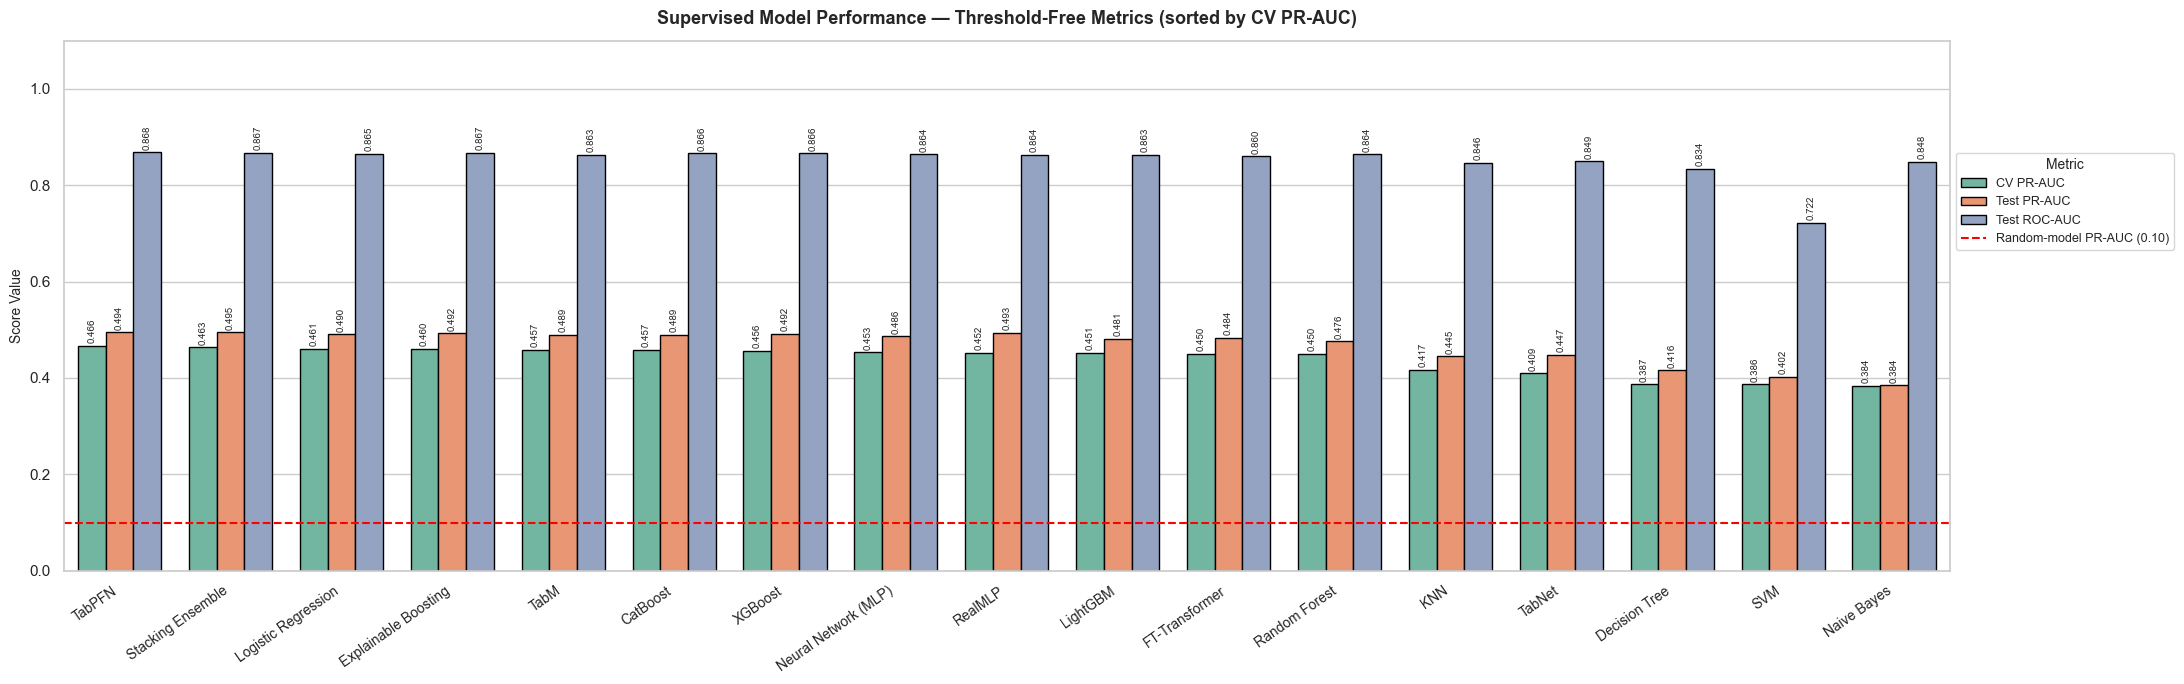

In [31]:
df_melted = df_comparison.reset_index()[['Model', 'CV PR-AUC', 'Test PR-AUC', 'Test ROC-AUC']].melt(
    id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(22, 7), dpi=100)
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='Set2', edgecolor='black', width=0.75)
ax.axhline(y_test.mean(), color='red', linestyle='--', lw=1.5, label=f'Random-model PR-AUC ({y_test.mean():.2f})')

plt.title('Supervised Model Performance — Threshold-Free Metrics (sorted by CV PR-AUC)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('')
plt.ylabel('Score Value', fontsize=10)
plt.ylim(0, 1.1)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.legend(title='Metric', loc='upper left', bbox_to_anchor=(1, 0.8), fontsize=9, title_fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=7, rotation=90)

plt.tight_layout()
save_figure("model_comparison_barchart.png")
plt.show()

* **A plateau at the top:** the best eight models are packed within **0.013 CV PR-AUC** of each other. TabPFN 0.466, Stacking 0.463, **Logistic Regression 0.461**, Explainable Boosting 0.460, TabM 0.457, CatBoost 0.457, XGBoost 0.456, MLP 0.453. That spread is about the size of one standard error (≈ 0.012), so their order is mostly noise.
* **Test set agrees:** the top group scores **0.48–0.49 test PR-AUC** and **0.86–0.87 ROC-AUC**, about **5×** the 0.10 PR-AUC of random guessing.
* **Modern models do not beat the classics.** TabPFN, TabM, RealMLP and FT-Transformer land in the same band as logistic regression and gradient boosting, and TabNet (0.409) is near the bottom. With 21 mostly questionnaire inputs and weak individual signals, the data, not the model family, sets the ceiling.
* **Clear losers:** KNN 0.417, Decision Tree 0.387, SVM 0.386 (test ROC-AUC 0.72) and Naive Bayes 0.384.
* **SMOTE:** cross-validation switched oversampling **off for every model except Naive Bayes**. Synthetic minority samples did not improve how well the models rank real patients.
* Accuracy is 0.91 for almost every model, which only confirms that it cannot tell them apart.

### Confusion Matrix

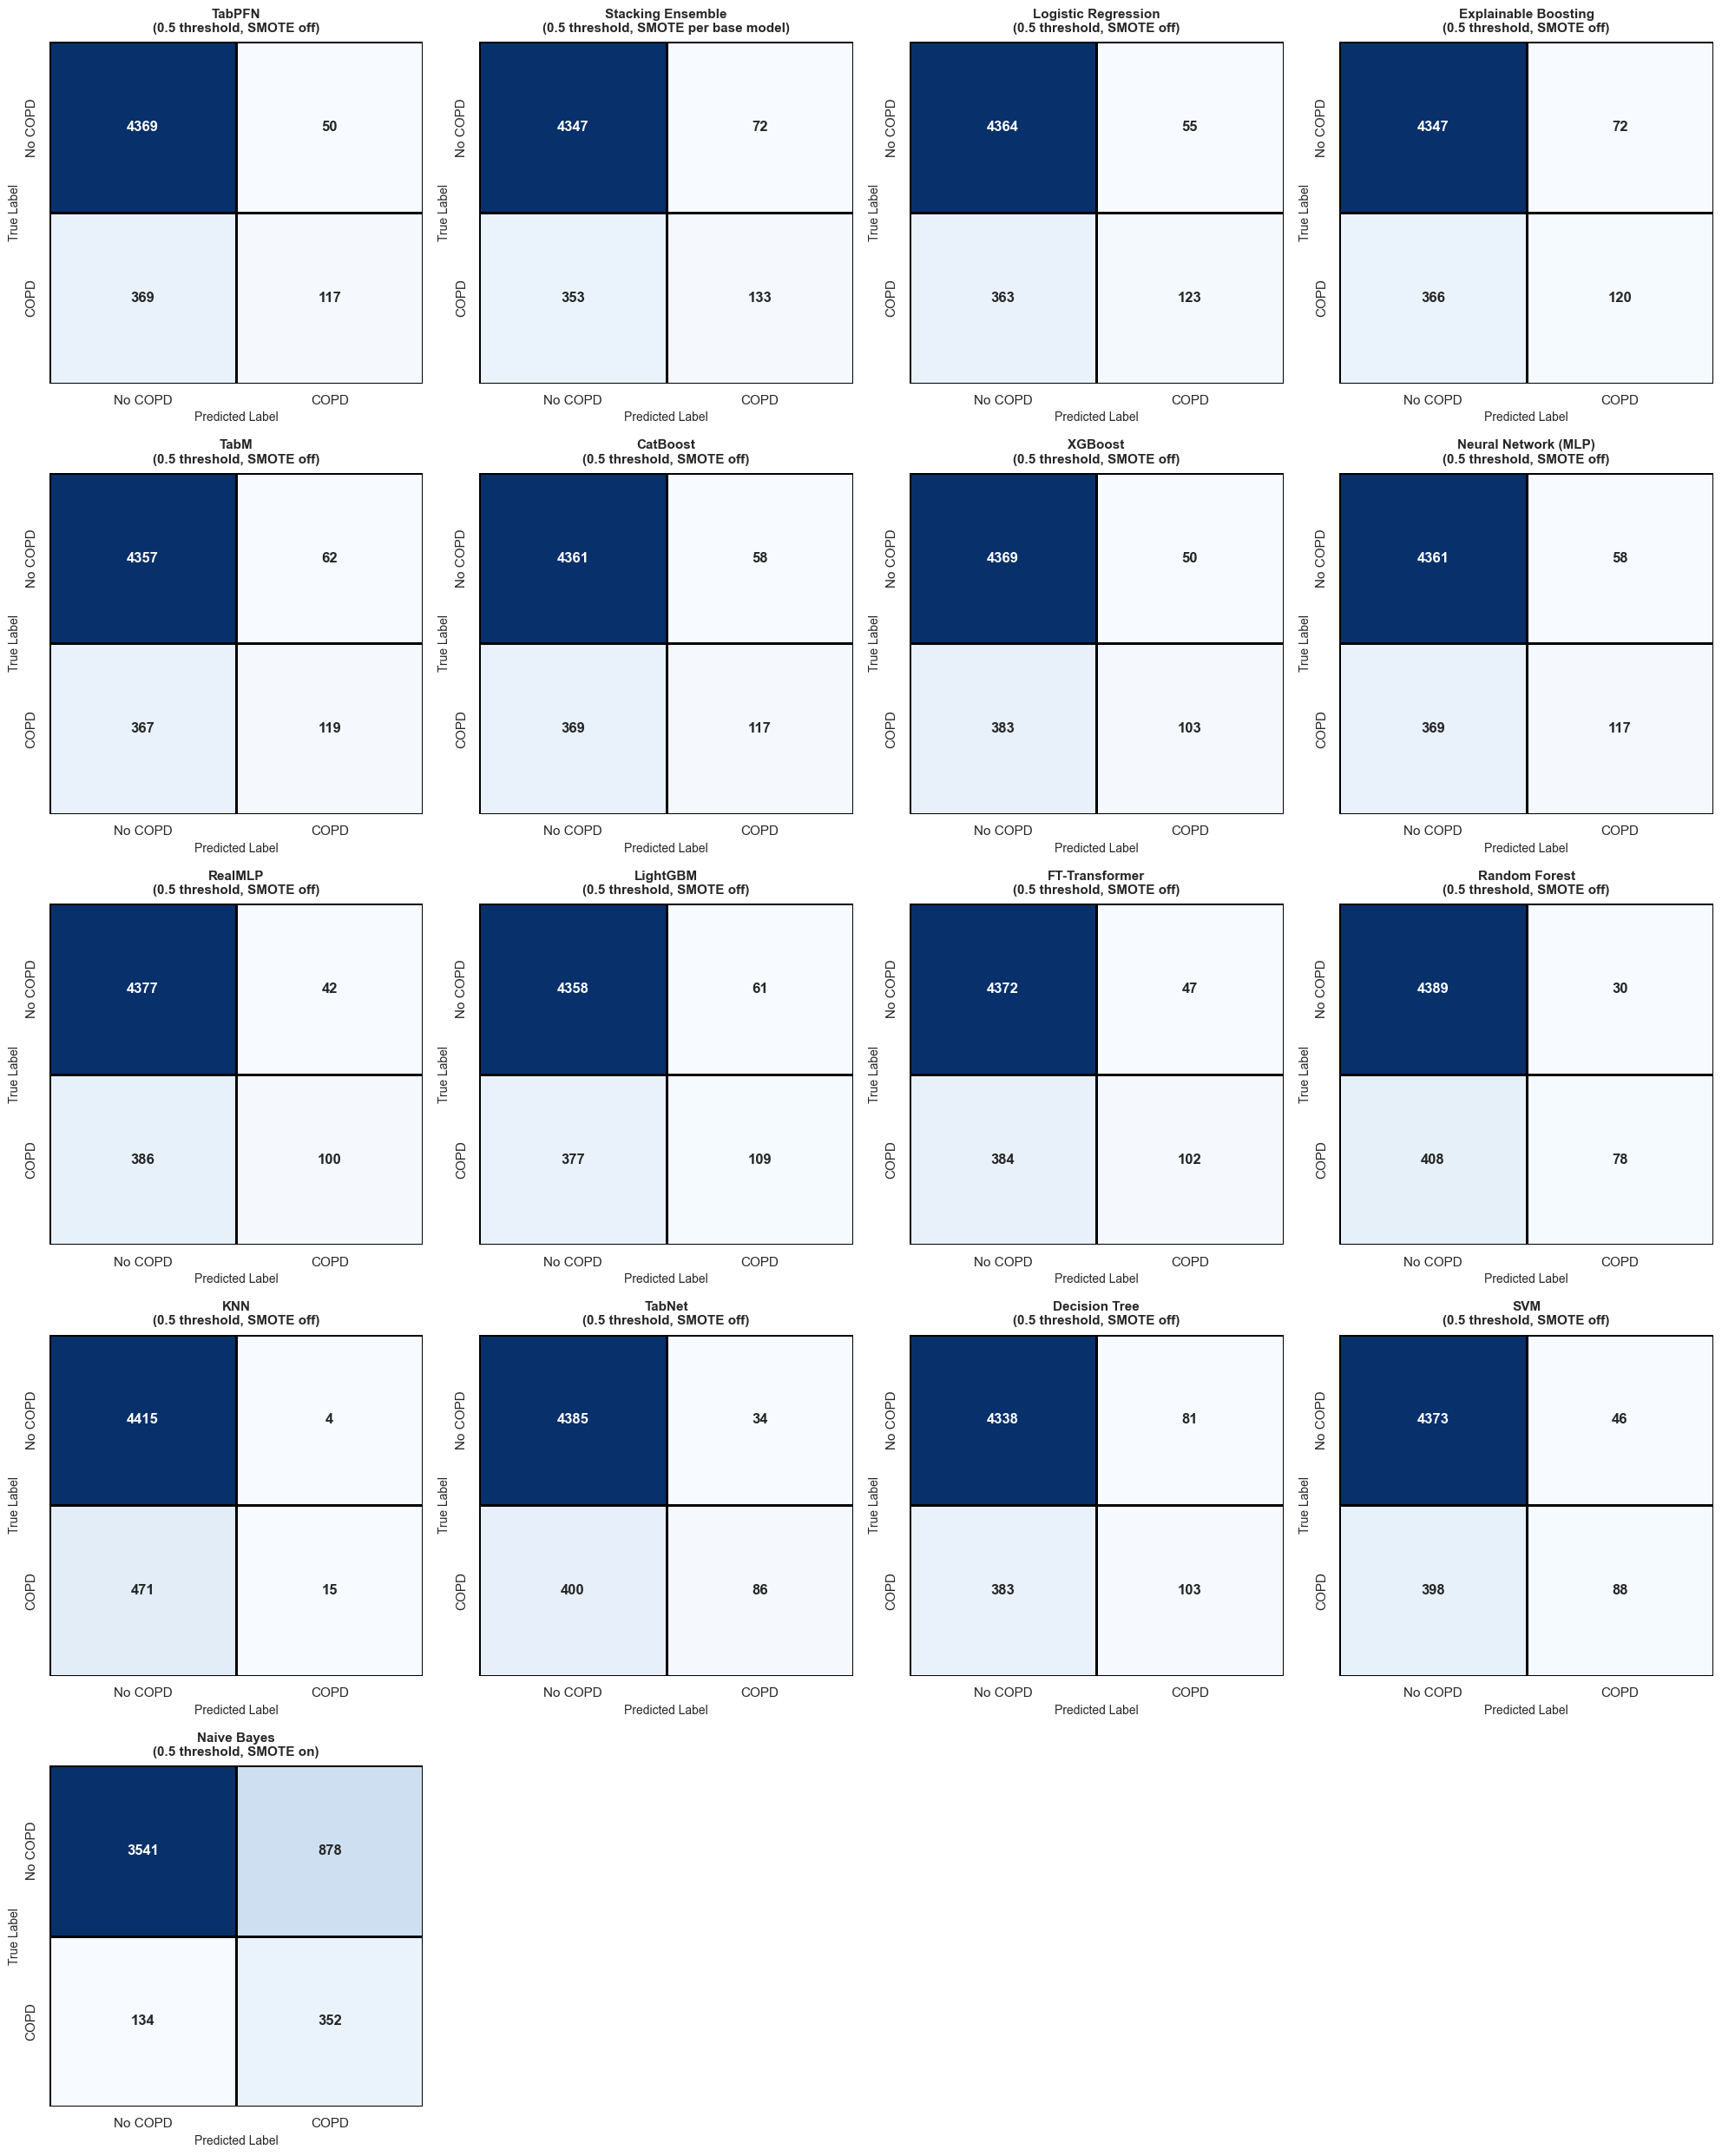

In [32]:
fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten()

for i, name in enumerate(df_comparison.index):
    cm = confusion_matrix(y_test, fitted_models[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No COPD', 'COPD'], yticklabels=['No COPD', 'COPD'],
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=1, linecolor='black', ax=axes[i])
    axes[i].set_title(f"{name}\n(0.5 threshold, SMOTE {cv_summary[name]['SMOTE']})", fontsize=11, fontweight='bold', pad=8)
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label', fontsize=10)

for j in range(len(df_comparison), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
save_figure("models_confusion_matrix.png")
plt.show()

* **At the default 0.5 threshold almost every model misses most COPD patients.** Recall is 16–27 %: Logistic Regression catches 123 of 486 and misses **363**, Random Forest misses 408, and KNN catches only 15 (3 %).
* **Naive Bayes is the exception, with 72 % recall**, only because cross-validation chose SMOTE for it. Training on artificially balanced classes shifts its probabilities upward, and it pays with **878 false alarms**.
* This is not a model failure: well-calibrated probabilities for a 10 % condition rarely exceed 0.5. The 0.5 cut-off is the wrong operating point, so the threshold is chosen explicitly below.

### ROC, PR Curve

AUC (area under the curve) measures a model's ability to tell the classes apart: 0.5 is random guessing, 1.0 is perfect. For imbalanced data the PR curve is the more demanding view, because its baseline is the prevalence (0.10), not 0.5.

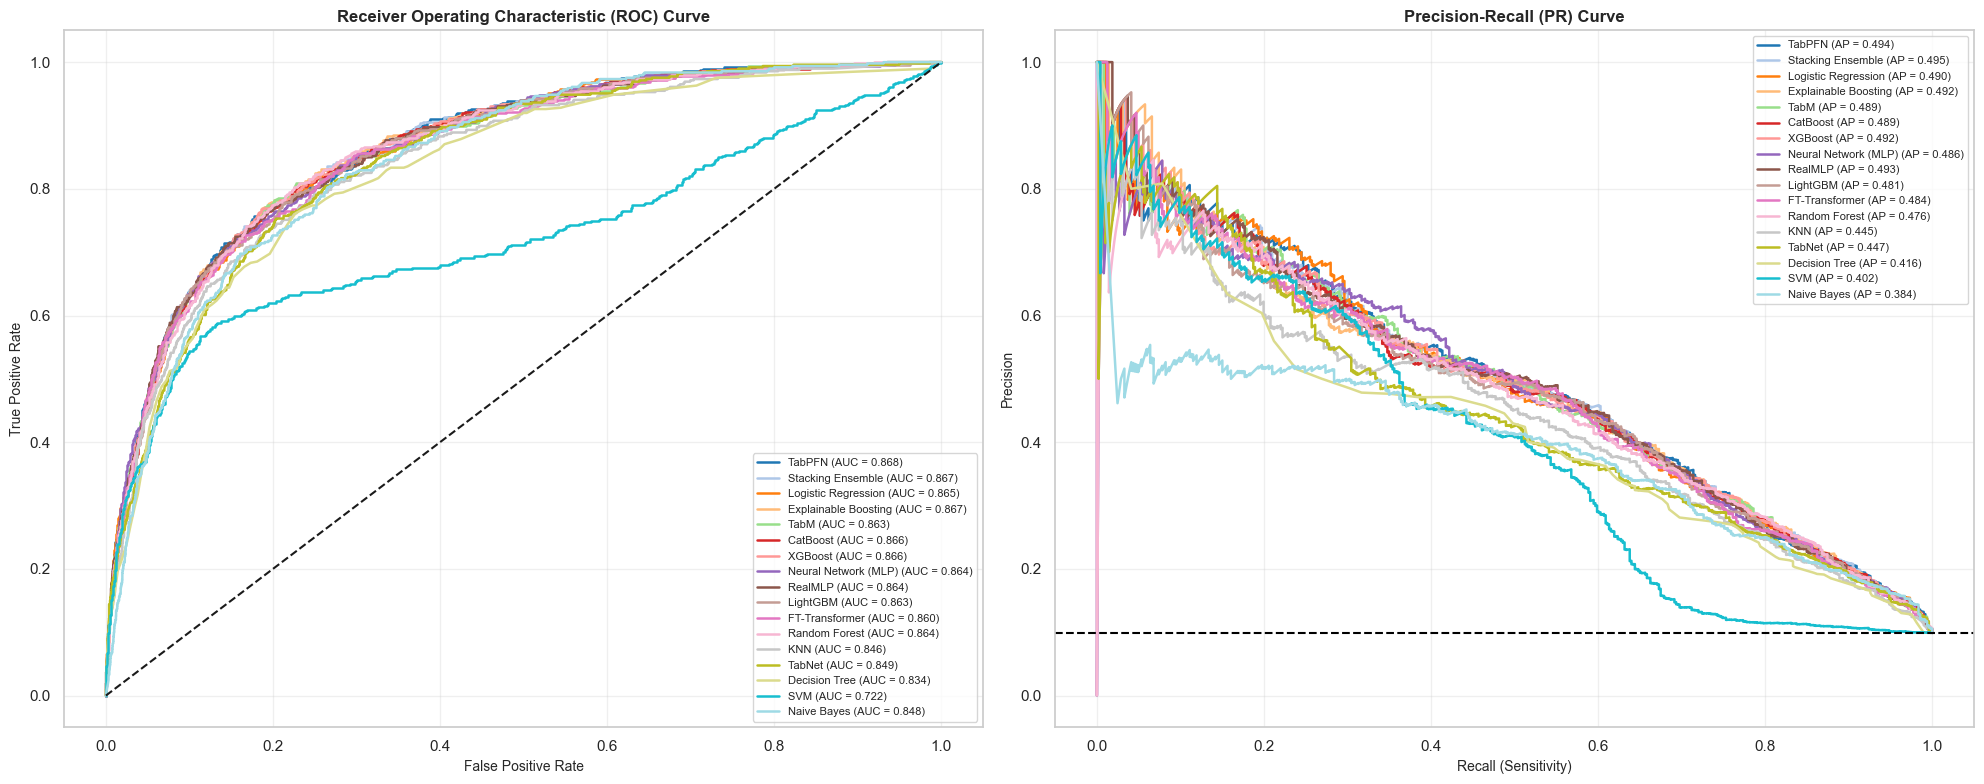

In [33]:
plt.figure(figsize=(20, 8), dpi=100)
ax_roc = plt.subplot(1, 2, 1)
ax_pr = plt.subplot(1, 2, 2)
colors = plt.cm.tab20(np.linspace(0, 1, len(df_comparison)))

for color, name in zip(colors, df_comparison.index):
    scores = test_scores[name]
    fpr, tpr, _ = roc_curve(y_test, scores)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, scores)
    ax_roc.plot(fpr, tpr, color=color, lw=1.8, label=f"{name} (AUC = {df_comparison.loc[name, 'Test ROC-AUC']:.3f})")
    ax_pr.plot(recall_vals, precision_vals, color=color, lw=1.8, label=f"{name} (AP = {df_comparison.loc[name, 'Test PR-AUC']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate', fontsize=10)
ax_roc.set_ylabel('True Positive Rate', fontsize=10)
ax_roc.legend(loc='lower right', fontsize=8)
ax_roc.grid(True, alpha=0.3)

ax_pr.axhline(y_test.mean(), color='black', linestyle='--', lw=1.5)
ax_pr.set_title('Precision-Recall (PR) Curve', fontsize=12, fontweight='bold')
ax_pr.set_xlabel('Recall (Sensitivity)', fontsize=10)
ax_pr.set_ylabel('Precision', fontsize=10)
ax_pr.legend(loc='upper right', fontsize=8)
ax_pr.grid(True, alpha=0.3)

plt.tight_layout()
save_figure("roc_pr_curve.png")
plt.show()

* **ROC:** all curves except the SVM (AUC 0.72) lie close together between 0.83 and 0.87, which is good discrimination for a self-reported diagnosis.
* **Precision–Recall:** precision starts around 0.6–0.7 for the highest-risk patients and falls to about 0.25–0.3 at 80 % recall. Every model stays well above the 0.10 prevalence line. Catching most COPD cases means flagging several healthy people per true case, which is acceptable for a referral to cheap, non-invasive spirometry.

# Best Supervised Model

**Selection rule — one standard error.** Picking the single highest score over-reads noise: the top models here differ by less than their own fold-to-fold variation. Following Breiman et al. (1984) and Hastie et al. (2009), we take the best CV PR-AUC, subtract one standard error, and choose the **simplest** model that clears that bar. "Simplest" means most interpretable and cheapest to deploy: glass-box models, then tree ensembles, then deep models, then foundation models and ensembles. Only training-set cross-validation is used, never the test set.

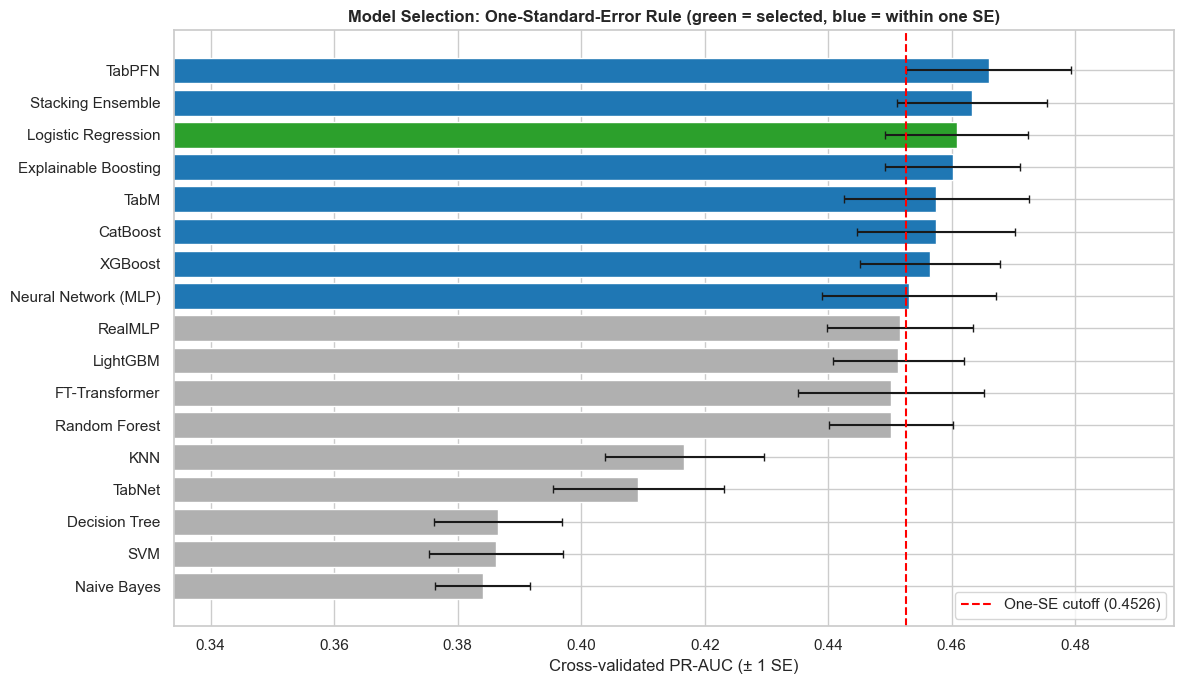

Highest CV PR-AUC     : TabPFN (0.4660 ± 0.0134 SE)
One-SE cutoff         : 0.4526
Models within one SE  : ['Logistic Regression', 'Explainable Boosting', 'XGBoost', 'CatBoost', 'Neural Network (MLP)', 'TabM', 'TabPFN', 'Stacking Ensemble']

🏆 The Best Model is: Logistic Regression
CV PR-AUC   : 0.4608 (Primary)
Test PR-AUC : 0.4903
Test ROC-AUC: 0.8648


In [34]:
# Simplest -> most complex (interpretability and deployment cost)
complexity_order = ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Explainable Boosting', 'KNN', 'SVM',
                    'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost', 'Neural Network (MLP)', 'TabNet',
                    'RealMLP', 'TabM', 'FT-Transformer', 'TabPFN', 'Stacking Ensemble']

top_model = df_comparison['CV PR-AUC'].idxmax()
top_score, top_se = df_comparison.loc[top_model, ['CV PR-AUC', 'CV SE']]
one_se_cutoff = top_score - top_se
within_one_se = [m for m in complexity_order
                 if m in df_comparison.index and df_comparison.loc[m, 'CV PR-AUC'] >= one_se_cutoff]
best_model_name = within_one_se[0]

plt.figure(figsize=(12, 7))
ranked = df_comparison.sort_values('CV PR-AUC')
bar_colors = ['#2ca02c' if m == best_model_name else ('#1f77b4' if m in within_one_se else '#b0b0b0') for m in ranked.index]
plt.barh(ranked.index, ranked['CV PR-AUC'], xerr=ranked['CV SE'], color=bar_colors, capsize=3)
plt.axvline(one_se_cutoff, color='red', linestyle='--', lw=1.5, label=f'One-SE cutoff ({one_se_cutoff:.4f})')
plt.xlim(ranked['CV PR-AUC'].min() - 0.05, top_score + 0.03)
plt.xlabel('Cross-validated PR-AUC (± 1 SE)')
plt.title('Model Selection: One-Standard-Error Rule (green = selected, blue = within one SE)', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
save_figure("model_selection_one_se.png")
plt.show()

print(f"Highest CV PR-AUC     : {top_model} ({top_score:.4f} ± {top_se:.4f} SE)")
print(f"One-SE cutoff         : {one_se_cutoff:.4f}")
print(f"Models within one SE  : {within_one_se}")
print(f"\n🏆 The Best Model is: {best_model_name}")
print(f"CV PR-AUC   : {df_comparison.loc[best_model_name, 'CV PR-AUC']:.4f} (Primary)")
print(f"Test PR-AUC : {df_comparison.loc[best_model_name, 'Test PR-AUC']:.4f}")
print(f"Test ROC-AUC: {df_comparison.loc[best_model_name, 'Test ROC-AUC']:.4f}")

* **TabPFN has the highest CV PR-AUC (0.4660 ± 0.0134)**, giving a one-SE cutoff of 0.4526. **Eight models clear it.**
* **The rule picks the simplest: Logistic Regression** (L1 penalty, C = 0.1): CV PR-AUC 0.4608, **test PR-AUC 0.490, test ROC-AUC 0.865**.
* Choosing TabPFN would add a 260 MB pre-trained transformer and a GPU dependency for a +0.005 CV gain that is a third of its own standard error. Logistic Regression gives the same ranking quality with coefficients a clinician can read.
* This is the same model `python -m src.train --compare` selected from a smaller pool, so the deployed artifacts written at the end of this notebook carry the same threshold and test metrics as before.

### Model Calibration
The deployed model has to output probabilities we can say out loud ("a 30 % chance of COPD"), and the decision threshold must be set on *those* probabilities. So calibration comes before threshold analysis. `CalibratedClassifierCV` fits isotonic regression on held-out folds of the original, un-oversampled data, which also removes any probability inflation left by SMOTE.

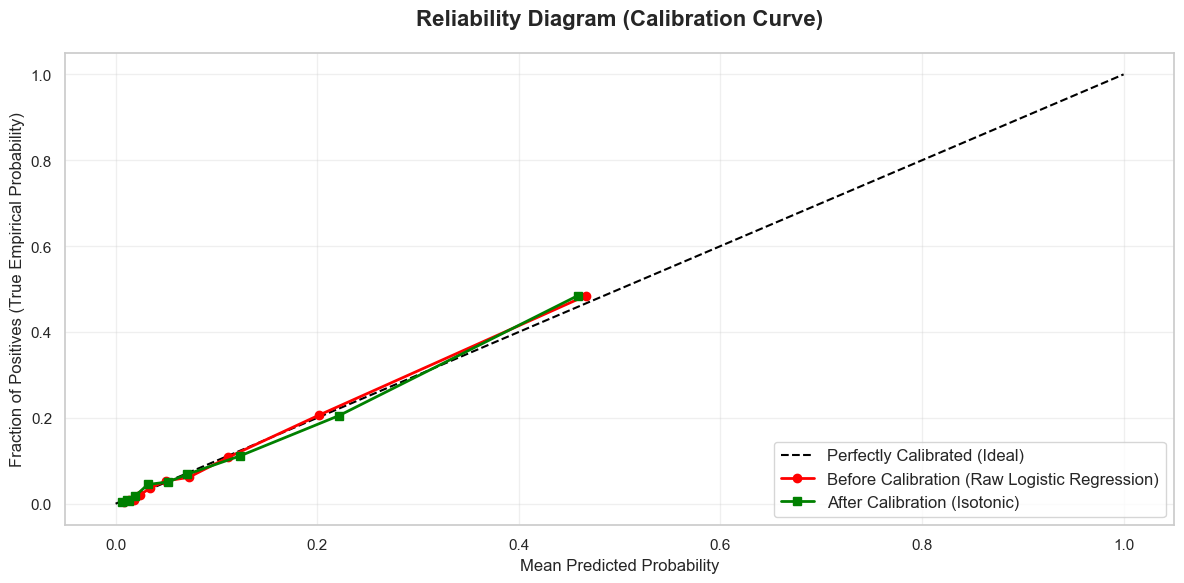

In [35]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Wrap the winning pipeline with a CalibratedClassifierCV
# cv=3 will cross-validate and retrain the model internally to avoid data leakage during calibration
winner_model = fitted_models[best_model_name]
calibrated_clf = CalibratedClassifierCV(estimator=winner_model, method='isotonic', cv=3)
calibrated_clf.fit(X_train, y_train)

raw_probas = positive_scores(winner_model, X_test)
calib_probas = calibrated_clf.predict_proba(X_test)[:, 1]
has_raw_probabilities = hasattr(winner_model, 'predict_proba')   # SVM only has a decision function

# We use strategy='quantile' since the dataset is imbalanced
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calib_probas, n_bins=10, strategy='quantile')

plt.figure(figsize=(12, 6), dpi=100)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated (Ideal)')
if has_raw_probabilities:
    prob_true_raw, prob_pred_raw = calibration_curve(y_test, raw_probas, n_bins=10, strategy='quantile')
    plt.plot(prob_pred_raw, prob_true_raw, marker='o', color='red', lw=2, label=f'Before Calibration (Raw {best_model_name})')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', color='green', lw=2, label='After Calibration (Isotonic)')

plt.title('Reliability Diagram (Calibration Curve)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives (True Empirical Probability)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_figure("reliability_diagram.png")
plt.show()

### Threshold Analysis
The threshold is chosen on **out-of-fold predictions from the training set**: every training patient is scored by a calibrated model that never saw them. Tuning it on the test set, as the kidney notebook did, would make the reported test metrics optimistic.

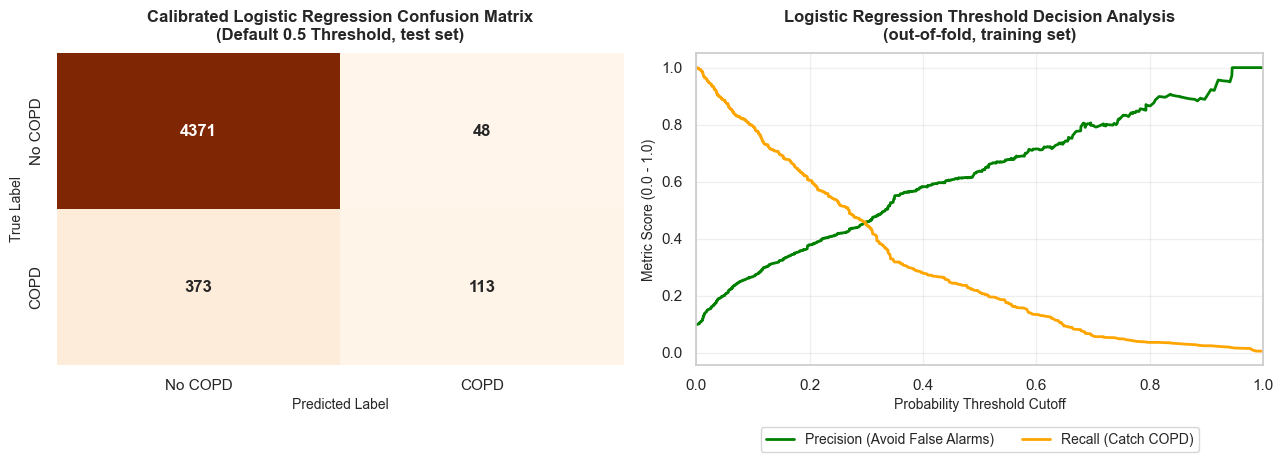


========================= OPERATIONAL CLINICAL IMPACT TABLE (test set) =========================


,Caught COPD (True Positives),Missed COPD (False Negatives),False Alarms (False Positives),Recall,Healthy Flagged Rate
Threshold,,,,,
0.05,439,47,1783,90.3%,40.3%
0.10,391,95,1064,80.5%,24.1%
0.15,342,144,667,70.4%,15.1%
0.20,317,169,498,65.2%,11.3%
0.30,234,252,246,48.1%,5.6%
0.50,113,373,48,23.3%,1.1%


In [36]:
oof_jobs = 1 if best_model_name in GPU_MODELS else min(5, N_JOBS)
oof_probas = cross_val_predict(
    CalibratedClassifierCV(estimator=clone(winner_model), method='isotonic', cv=3),
    X_train, y_train, cv=cv_strategy, method='predict_proba', n_jobs=oof_jobs
)[:, 1]

plt.figure(figsize=(13, 5), dpi=100)

# Test-set confusion matrix at the default 0.5 threshold on calibrated probabilities
default_preds = np.where(calib_probas >= 0.5, 1, 0)
cm = confusion_matrix(y_test, default_preds)
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['No COPD', 'COPD'], yticklabels=['No COPD', 'COPD'],
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title(f'Calibrated {best_model_name} Confusion Matrix\n(Default 0.5 Threshold, test set)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

# THRESHOLD OVERLAY ANALYSIS (out-of-fold training predictions)
precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probas)
plt.subplot(1, 2, 2)
plt.plot(thresholds, precisions[:-1], label='Precision (Avoid False Alarms)', color='green', lw=2)
plt.plot(thresholds, recalls[:-1], label='Recall (Catch COPD)', color='orange', lw=2)
plt.title(f'{best_model_name} Threshold Decision Analysis\n(out-of-fold, training set)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Probability Threshold Cutoff', fontsize=10)
plt.ylabel('Metric Score (0.0 - 1.0)', fontsize=10)
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2, fontsize=10)

plt.tight_layout()
plt.show()

# SIMULATION TABLE (test set, calibrated probabilities)
simulation_data = []
for t in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
    sim_preds = np.where(calib_probas >= t, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, sim_preds).ravel()
    simulation_data.append({
        'Threshold': t,
        'Caught COPD (True Positives)': tp,
        'Missed COPD (False Negatives)': fn,
        'False Alarms (False Positives)': fp,
        'Recall': f"{tp / (tp + fn):.1%}",
        'Healthy Flagged Rate': f"{fp / (tn + fp):.1%}"
    })

df_sim = pd.DataFrame(simulation_data).set_index('Threshold')
print("\n========================= OPERATIONAL CLINICAL IMPACT TABLE (test set) =========================")
display(df_sim)

* **0.5 is far too strict:** the calibrated model then catches only **113 of 486** COPD patients (23 %).
* Lowering the threshold trades false alarms for caught cases: **0.10** catches 80.5 % while flagging 24 % of healthy adults; **0.05** catches 90 % but flags 40 %.
* The right-hand plot shows the same trade-off on out-of-fold *training* predictions: recall falls and precision rises as the threshold increases. The cost-based search below picks the point on these training curves; the test set is used only to report the result.

### Automated Cost-Based Threshold Optimization

A missed COPD case (False Negative) is penalised 5 and an unnecessary spirometry referral (False Positive) 1 — the same 5:1 ratio as the heart and kidney modules. Here the cost is summed over **patient counts** (5·FN + 1·FP), which is the actual clinical cost. For perfectly calibrated probabilities, decision theory puts the optimum at *p* = 1 / (1 + 5) ≈ 0.167, a useful cross-check on the empirical result.

Automatically determined optimal threshold (out-of-fold, training set): 0.1637
Bayes-optimal threshold for perfectly calibrated probabilities:           0.1667

=== Metrics at Optimal Threshold (test set) ===
Recall (Sensitivity) : 0.6893
Precision            : 0.3464
F1-Score             : 0.4611
Specificity          : 0.8570


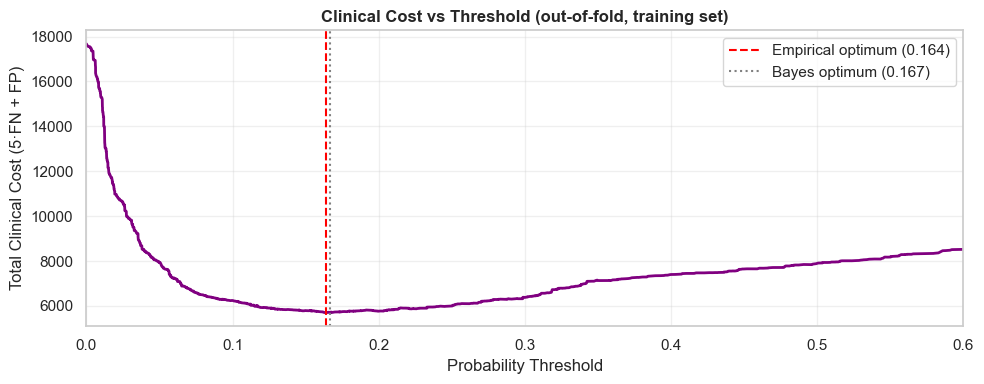

In [37]:
FN_COST, FP_COST = 5, 1

candidate_thresholds = np.unique(oof_probas)
positives = (y_train.values == 1)
total_cost = np.array([FN_COST * np.sum(positives & (oof_probas < t)) + FP_COST * np.sum(~positives & (oof_probas >= t))
                       for t in candidate_thresholds])

best_threshold = float(candidate_thresholds[np.argmin(total_cost)])
bayes_threshold = FP_COST / (FP_COST + FN_COST)

print(f"Automatically determined optimal threshold (out-of-fold, training set): {best_threshold:.4f}")
print(f"Bayes-optimal threshold for perfectly calibrated probabilities:           {bayes_threshold:.4f}\n")

# Apply the training-set threshold to the untouched test set
sim_preds_best = np.where(calib_probas >= best_threshold, 1, 0)

print("=== Metrics at Optimal Threshold (test set) ===")
print(f"Recall (Sensitivity) : {recall_score(y_test, sim_preds_best):.4f}")
print(f"Precision            : {precision_score(y_test, sim_preds_best):.4f}")
print(f"F1-Score             : {f1_score(y_test, sim_preds_best):.4f}")
tn, fp, fn, tp = confusion_matrix(y_test, sim_preds_best).ravel()
print(f"Specificity          : {tn / (tn + fp):.4f}")

plt.figure(figsize=(10, 4))
plt.plot(candidate_thresholds, total_cost, color='purple', lw=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Empirical optimum ({best_threshold:.3f})')
plt.axvline(bayes_threshold, color='gray', linestyle=':', label=f'Bayes optimum ({bayes_threshold:.3f})')
plt.xlim(0, 0.6)
plt.xlabel('Probability Threshold')
plt.ylabel('Total Clinical Cost (5·FN + FP)')
plt.title('Clinical Cost vs Threshold (out-of-fold, training set)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Best Threshold In Confusion Matrix

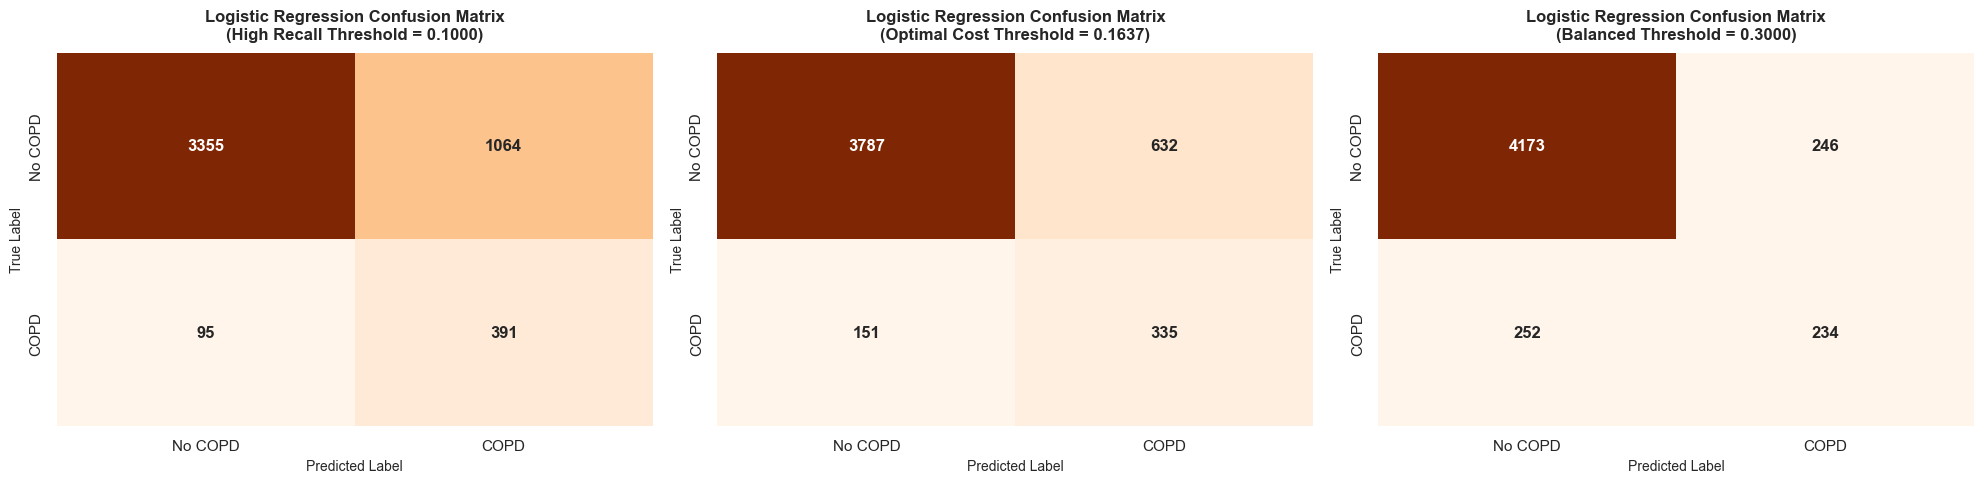

In [38]:
# Visualize Confusion Matrices for the top selected operational thresholds
plt.figure(figsize=(20, 5), dpi=100)
operating_points = [(0.10, 'High Recall Threshold'), (best_threshold, 'Optimal Cost Threshold'), (0.30, 'Balanced Threshold')]

for i, (t, label) in enumerate(operating_points, start=1):
    cm_t = confusion_matrix(y_test, np.where(calib_probas >= t, 1, 0))
    plt.subplot(1, 3, i)
    sns.heatmap(cm_t, annot=True, fmt='d', cmap='Oranges', cbar=False,
                xticklabels=['No COPD', 'COPD'], yticklabels=['No COPD', 'COPD'],
                annot_kws={'size': 12, 'weight': 'bold'})
    plt.title(f'{best_model_name} Confusion Matrix\n({label} = {t:.4f})', fontsize=12, fontweight='bold', pad=10)
    plt.xlabel('Predicted Label', fontsize=10)
    plt.ylabel('True Label', fontsize=10)

plt.tight_layout()
save_figure("optimal_threshold_confusion_matrix.png")
plt.show()

In [39]:
def operating_metrics(label, probas, threshold):
    preds = np.where(probas >= threshold, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    return {'Model': label, 'Accuracy': accuracy_score(y_test, preds),
            'Precision': precision_score(y_test, preds, zero_division=0),
            'Recall': recall_score(y_test, preds, zero_division=0),
            'F1-Score': f1_score(y_test, preds, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, probas), 'PR-AUC (AP)': average_precision_score(y_test, probas),
            'Missed Patients (FN)': int(fn), 'False Alarms (FP)': int(fp)}

calibration_rows = [operating_metrics(f'Calibrated {best_model_name} @ 0.5', calib_probas, 0.5),
                    operating_metrics(f'Calibrated {best_model_name} @ {best_threshold:.3f} (optimal)', calib_probas, best_threshold)]
if has_raw_probabilities:
    calibration_rows.insert(0, operating_metrics(f'Raw {best_model_name} @ 0.5', raw_probas, 0.5))
df_calib_comp = pd.DataFrame(calibration_rows).set_index('Model')

print("================================ CALIBRATION PERFORMANCE COMPARISON ================================")
display(df_calib_comp.style.background_gradient(
    cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC (AP)']
).background_gradient(
    cmap='Reds', subset=['Missed Patients (FN)', 'False Alarms (FP)']
).format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}', 'PR-AUC (AP)': '{:.4f}',
    'Missed Patients (FN)': '{:,.0f}', 'False Alarms (FP)': '{:,.0f}'
}))

================================ CALIBRATION PERFORMANCE COMPARISON ================================


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC (AP),Missed Patients (FN),False Alarms (FP)
Model,,,,,,,,
Raw Logistic Regression @ 0.5,0.9148,0.6910,0.2531,0.3705,0.8648,0.4903,363,55
Calibrated Logistic Regression @ 0.5,0.9142,0.7019,0.2325,0.3493,0.8640,0.4804,373,48
Calibrated Logistic Regression @ 0.164 (optimal),0.8404,0.3464,0.6893,0.4611,0.8640,0.4804,151,632


* **The cost-optimal threshold is 0.164**, almost exactly the Bayes-optimal 1/(1+5) = 0.167 for perfectly calibrated probabilities. The model's probabilities can be taken at face value.
* At that threshold on the **test set**: **recall 0.689** (335 of 486 caught, 151 missed), **precision 0.346**, **specificity 0.857**, F1 0.461. That means **632 false alarms** in 4,905 adults: about 1.9 false alarms for every COPD case found, or 2.9 referrals per case. At 0.5 the model would miss 373 patients but raise only 48 false alarms.
* **Calibration was not needed for this model:** the reliability diagram shows raw Logistic Regression already on the diagonal. Isotonic calibration slightly *lowers* ranking quality (test PR-AUC 0.490 → 0.480) and leaves the Brier score unchanged (0.0664 raw vs 0.0666 calibrated, against 0.0893 for always predicting the prevalence). It is kept so every module ships the same calibrated pipeline, and the cost is small.

### Bootstrapped Confidence Intervals (Model Reliability)

In medical literature, point estimates (like Recall = 0.80) are rarely reported alone. Because the test set is one sample of the population, we need to know how much each metric would move on another sample of patients.

Bootstrapping (resampling the test set with replacement) simulates 1,000 test sets and evaluates the calibrated model at the optimal threshold on each. The 2.5th–97.5th percentiles give the 95 % confidence interval for each metric.

In [40]:
from sklearn.utils import resample

n_iterations = 1000
n_size = len(X_test)
y_test_array = y_test.values
test_preds = sim_preds_best

bootstrapped = {'Recall': [], 'Precision': [], 'ROC-AUC': [], 'PR-AUC': []}

for i in range(n_iterations):
    # Resample the indices with replacement
    indices = resample(np.arange(n_size), replace=True, n_samples=n_size, random_state=i)
    y_true_boot, y_pred_boot, y_proba_boot = y_test_array[indices], test_preds[indices], calib_probas[indices]

    # Ensure the bootstrap sample contains both classes to calculate AUCs safely
    if len(np.unique(y_true_boot)) < 2:
        continue

    bootstrapped['Recall'].append(recall_score(y_true_boot, y_pred_boot, zero_division=0))
    bootstrapped['Precision'].append(precision_score(y_true_boot, y_pred_boot, zero_division=0))
    bootstrapped['ROC-AUC'].append(roc_auc_score(y_true_boot, y_proba_boot))
    bootstrapped['PR-AUC'].append(average_precision_score(y_true_boot, y_proba_boot))

def calc_ci(metrics_list, alpha=0.95):
    lower_bound = np.percentile(metrics_list, (1 - alpha) / 2 * 100)
    upper_bound = np.percentile(metrics_list, (1 + alpha) / 2 * 100)
    return np.mean(metrics_list), lower_bound, upper_bound

confidence_intervals = {}
print(f"=== 95% Bootstrapped Confidence Intervals ({n_iterations} Iterations, threshold {best_threshold:.3f}) ===")
for metric, values in bootstrapped.items():
    mean_val, lower_val, upper_val = calc_ci(values)
    confidence_intervals[metric] = {'mean': mean_val, 'ci_lower': lower_val, 'ci_upper': upper_val}
    print(f"{metric:9s} : {mean_val:.3f} (95% CI: {lower_val:.3f} - {upper_val:.3f})")

=== 95% Bootstrapped Confidence Intervals (1000 Iterations, threshold 0.164) ===
Recall    : 0.690 (95% CI: 0.651 - 0.734)
Precision : 0.346 (95% CI: 0.319 - 0.376)
ROC-AUC   : 0.864 (95% CI: 0.847 - 0.880)
PR-AUC    : 0.482 (95% CI: 0.434 - 0.527)


* **Recall 0.690 (95 % CI 0.651–0.734)** and **precision 0.346 (0.319–0.376)** at the 0.164 threshold. On a new sample of this population the model would catch roughly two in three COPD patients, and about one in three referrals would have COPD.
* **ROC-AUC 0.864 (0.847–0.880)** and **PR-AUC 0.482 (0.434–0.527)**. The PR-AUC interval is about ±0.05 wide, three to four times the spread between the top eight models. This is more evidence that their ranking in the comparison table is noise.

### Brier Score

The Brier score is the mean squared difference between the predicted probability and the actual outcome (0 or 1). Lower is better: it measures calibration and sharpness together. At 9.9 % prevalence, always predicting 0.099 scores ≈ 0.089, which is the bar to beat.

In [41]:
from sklearn.metrics import brier_score_loss

brier_reference = brier_score_loss(y_test, np.full(len(y_test), y_train.mean()))
brier_calibrated = brier_score_loss(y_test, calib_probas)
print(f"Brier Score (Always predict prevalence): {brier_reference:.4f}")
if has_raw_probabilities:
    brier_raw = brier_score_loss(y_test, raw_probas)
    print(f"Brier Score (Raw {best_model_name}): {brier_raw:.4f}")
print(f"Brier Score (Calibrated {best_model_name}): {brier_calibrated:.4f}")

if has_raw_probabilities and brier_calibrated < brier_raw:
    print("\nInterpretation: The calibrated model has a lower Brier Score, indicating better calibration (its predicted probabilities are closer to the true probabilities).")
elif has_raw_probabilities and brier_calibrated > brier_raw:
    print("\nInterpretation: The raw model has a lower Brier Score; its probabilities were already well calibrated, and isotonic regression mainly adds a little variance.")

Brier Score (Always predict prevalence): 0.0893
Brier Score (Raw Logistic Regression): 0.0664
Brier Score (Calibrated Logistic Regression): 0.0666

Interpretation: The raw model has a lower Brier Score; its probabilities were already well calibrated, and isotonic regression mainly adds a little variance.


# Feature Importance

### SHAP

To understand what drives the predictions we use SHAP (SHapley Additive exPlanations). The explainer matches the model type: exact `TreeExplainer` for tree ensembles, `LinearExplainer` for logistic regression, and a model-agnostic permutation explainer otherwise. Values are on the base model's margin (log-odds) scale; isotonic calibration is a monotone re-mapping, so it doesn't change which features push a patient up or down.

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


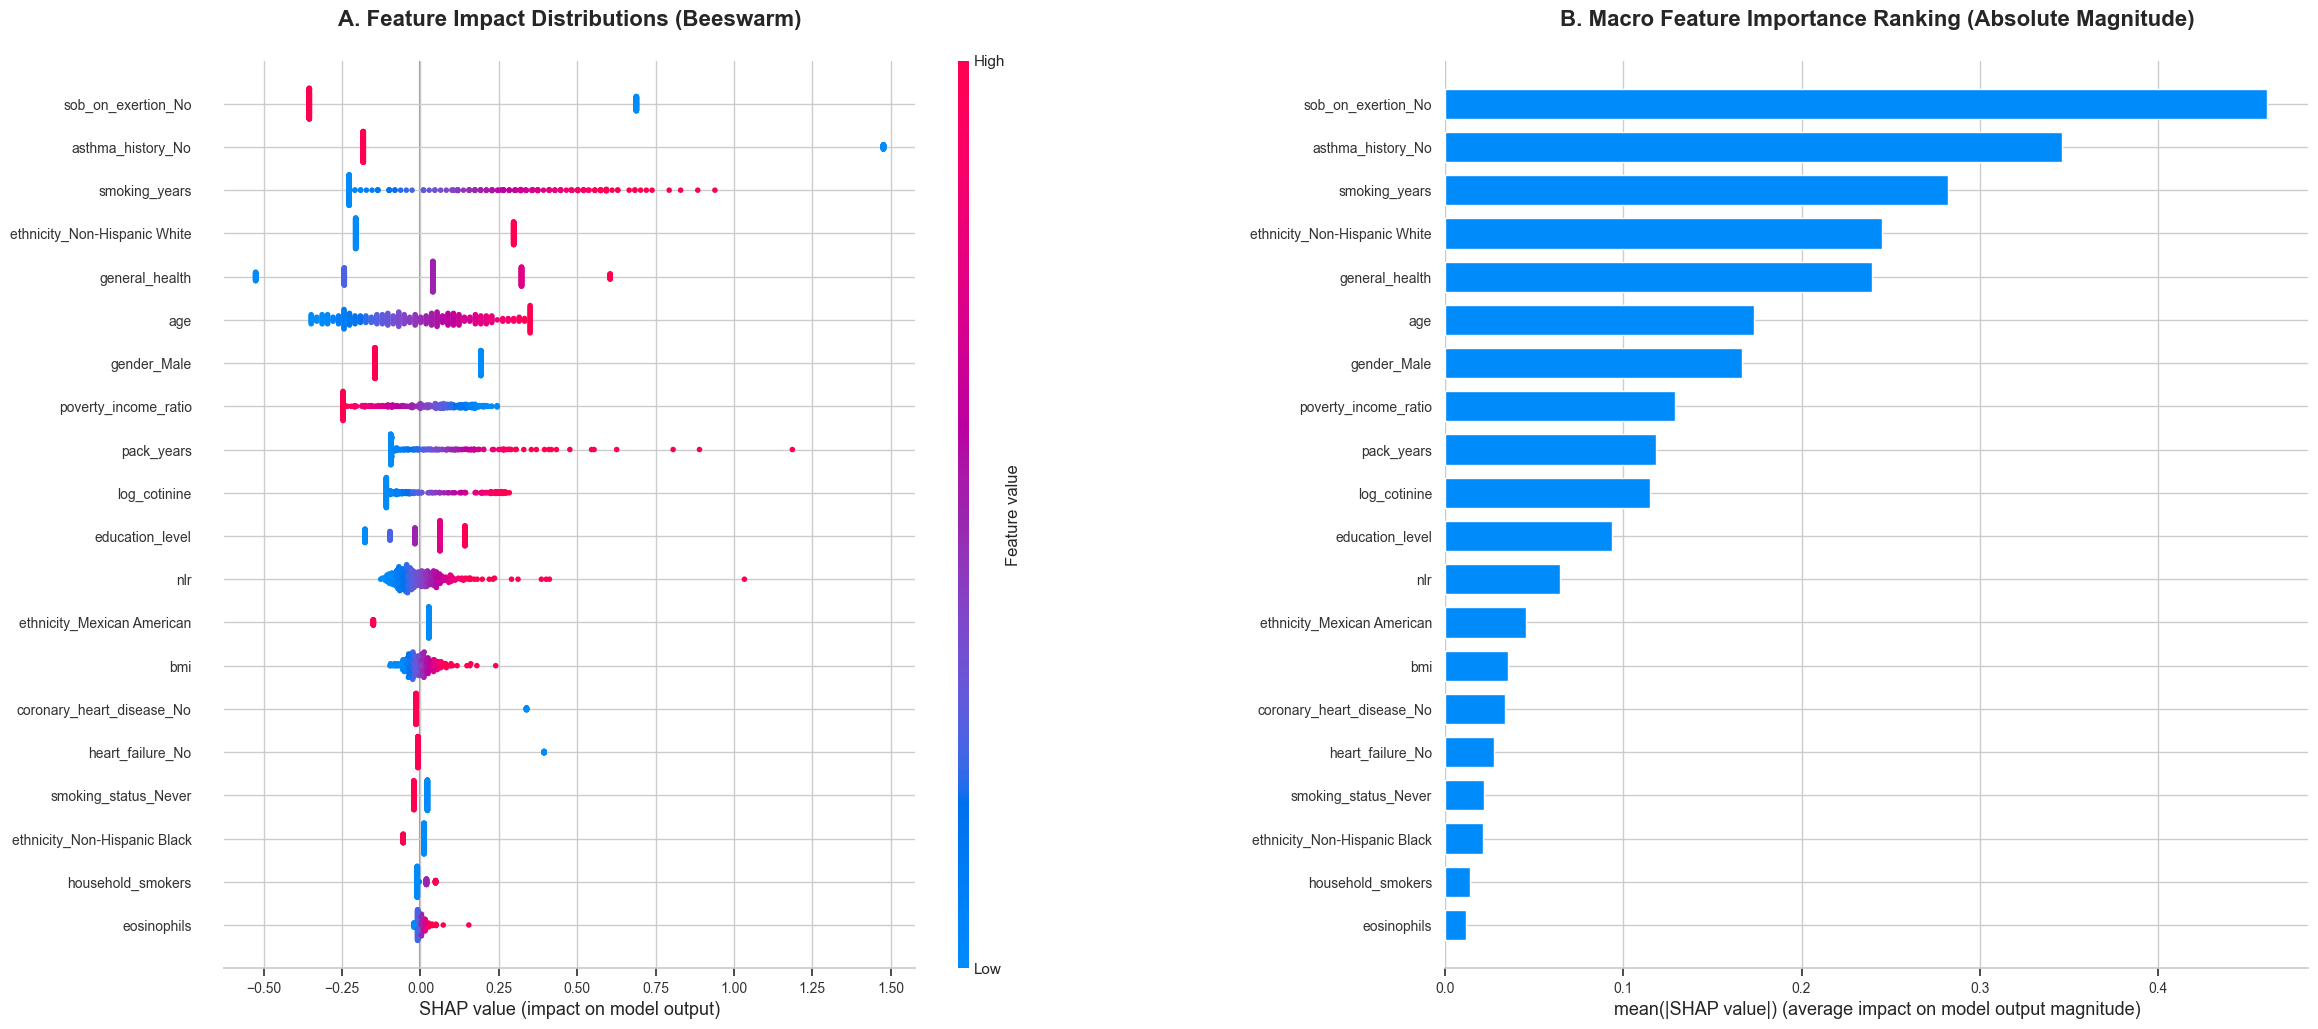

In [42]:
import shap
import matplotlib.gridspec as gridspec

# Stacking has no single classifier step; in that case explain the best single pipeline
pipeline_models = [m for m in df_comparison.index if hasattr(fitted_models[m], 'named_steps')]
explain_name = best_model_name if best_model_name in pipeline_models else pipeline_models[0]
if explain_name != best_model_name:
    print(f"{best_model_name} has no single classifier step; SHAP explains {explain_name} instead.")

# Extract the best pipeline and its components
best_pipeline = fitted_models[explain_name]
model_object = best_pipeline.named_steps['classifier']
preprocessor = best_pipeline[:-1]           # engineering -> imputation -> (SMOTENC skipped at transform) -> encoding

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = list(best_pipeline.named_steps['encoding'].get_feature_names_out())

tree_models = (XGBClassifier, LGBMClassifier, CatBoostClassifier, RandomForestClassifier, DecisionTreeClassifier)
fast_explainer = isinstance(model_object, tree_models + (LogisticRegression,))
slow_model = explain_name in GPU_MODELS

def build_shap_explainer(model, background):
    if isinstance(model, tree_models):
        return shap.TreeExplainer(model)
    if isinstance(model, LogisticRegression):
        return shap.LinearExplainer(model, background)
    # Model-agnostic permutation explainer; a small background keeps slow (GPU) models tractable
    masker = shap.maskers.Independent(background, max_samples=25 if slow_model else 50)
    return shap.explainers.Permutation(lambda data: positive_scores(model, data), masker, feature_names=feature_names)

def compute_shap(explainer, data):
    if isinstance(explainer, shap.explainers.Permutation):
        # One forward + one backward pass over the features: the minimum the explainer accepts
        values = explainer(data, max_evals=2 * data.shape[1] + 1, silent=True)
    else:
        values = explainer(data)
    if len(values.values.shape) == 3:          # (samples, features, classes) -> positive class
        values = values[..., 1]
    return values

background = shap.sample(X_train_processed, 200, random_state=RANDOM_STATE)
explainer = build_shap_explainer(model_object, background)

# Extract a sample array for SHAP (the model-agnostic explainer is far slower, so it gets fewer rows)
n_explain = 300 if fast_explainer else (50 if slow_model else 150)
X_sample = X_test_processed[:n_explain]
shap_values = compute_shap(explainer, X_sample)
shap_values.feature_names = feature_names

fig = plt.figure(figsize=(24, 10), dpi=100)
gs = gridspec.GridSpec(1, 21)
ax1 = plt.subplot(gs[0, 0:9])
ax2 = plt.subplot(gs[0, 12:21])

# --- LEFT PLOT: Feature Impact Distributions (Beeswarm) ---
plt.sca(ax1)
shap.summary_plot(shap_values.values, X_sample, feature_names=feature_names, max_display=20, show=False, plot_size=None)
ax1.set_title('A. Feature Impact Distributions (Beeswarm)', fontsize=16, fontweight='bold', pad=25)
ax1.tick_params(axis='both', labelsize=10)

# --- RIGHT PLOT: Average Absolute SHAP Value (Global Bar) ---
plt.sca(ax2)
shap.summary_plot(shap_values.values, X_sample, plot_type="bar", feature_names=feature_names, max_display=20, show=False, plot_size=None)
ax2.set_title('B. Macro Feature Importance Ranking (Absolute Magnitude)', fontsize=16, fontweight='bold', pad=25)
ax2.tick_params(axis='both', labelsize=10)

save_figure("shap_analysis_macro_feature_importance.png")
plt.show()

Logistic Regression is explained exactly by `LinearExplainer`; values are in log-odds.
* **Strongest individual pushes:** a history of **asthma** (+1.48 log-odds when present, −0.19 when absent) and **shortness of breath on exertion** (+0.69 when present, −0.35 when absent). Both are expected: asthma–COPD overlap is common and the two are often confused at diagnosis, and breathlessness is COPD's cardinal symptom.
* **Smoking duration** has the most even, monotonic effect (up to +0.9 for the longest smokers), with **pack-years** and **log-cotinine** adding a little on top.
* **Self-rated general health** (poor → up to +0.6), **age**, **female sex** (+0.2; men −0.15) and **lower income** raise the predicted risk. These track who *receives* a COPD diagnosis as much as who has the disease.
* **Non-Hispanic White ethnicity** (+0.3) is the fourth-largest feature. COPD is diagnosed more often in this group in NHANES; it is a population pattern the model has learned, not a biological cause.
* **Blood counts** (NLR, eosinophils) and BMI barely move the prediction.

### Permutation Importance

Global, model-agnostic importance. The **raw input columns** are shuffled one at a time and pushed through the full calibrated pipeline, so shuffling `cigarettes_per_day` also scrambles the `pack_years` built from it. The score drop is measured in PR-AUC.

--- Permutation Importance (drop in test PR-AUC when the column is shuffled) ---


,Feature,Importance_Mean,Importance_Std
12,asthma_history,0.152776,0.012518
9,smoking_years,0.072289,0.008504
15,sob_on_exertion,0.071452,0.010017
16,general_health,0.029541,0.004183
2,ethnicity,0.022479,0.004793
8,cigarettes_per_day,0.007807,0.004127
11,serum_cotinine,0.007588,0.003762
1,gender,0.007549,0.003307
4,poverty_income_ratio,0.006872,0.003768
13,heart_failure,0.002897,0.001506


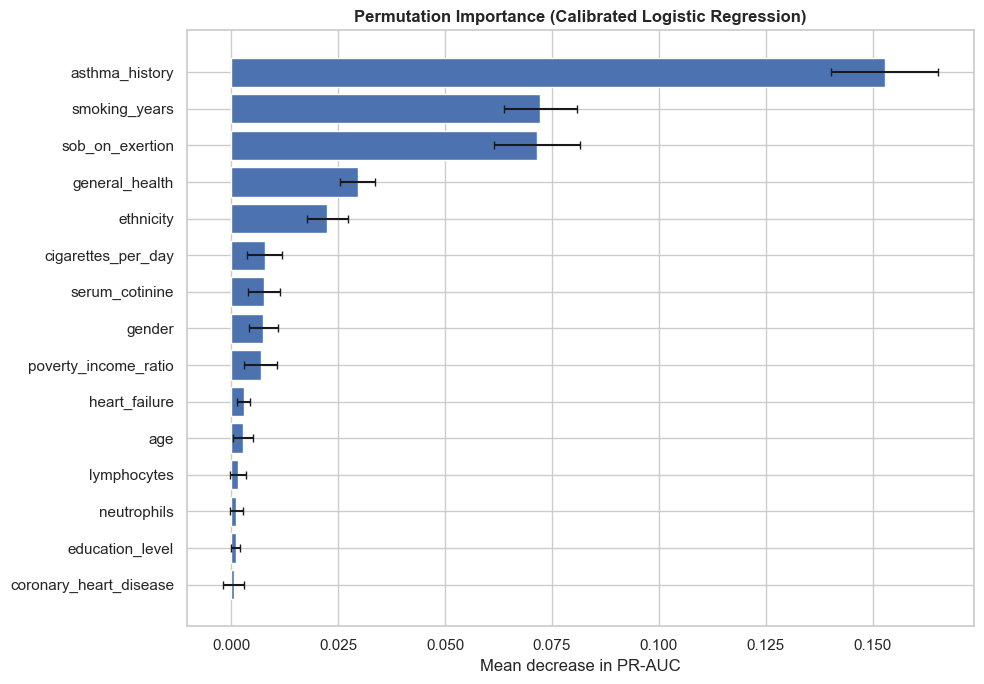

In [43]:
from sklearn.inspection import permutation_importance

perm_repeats = 3 if best_model_name in GPU_MODELS else 10
perm_jobs = 1 if best_model_name in GPU_MODELS else N_JOBS
result = permutation_importance(
    calibrated_clf, X_test, y_test, scoring='average_precision',
    n_repeats=perm_repeats, random_state=RANDOM_STATE, n_jobs=perm_jobs
)

# Format the results into a clean DataFrame
df_perm_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)
df_perm_importance.to_csv(os.path.join(results_dir, 'permutational_feature_importance.csv'), index=False)

print("--- Permutation Importance (drop in test PR-AUC when the column is shuffled) ---")
display(df_perm_importance.head(10))

plt.figure(figsize=(10, 7))
top_perm = df_perm_importance.head(15).iloc[::-1]
plt.barh(top_perm['Feature'], top_perm['Importance_Mean'], xerr=top_perm['Importance_Std'], color='#4c72b0', capsize=3)
plt.xlabel('Mean decrease in PR-AUC')
plt.title(f'Permutation Importance (Calibrated {best_model_name})', fontweight='bold')
plt.tight_layout()
save_figure("permutation_importance.png")
plt.show()

* Shuffling **asthma history** drops test PR-AUC by **0.153** (about a third of the model's total). **Smoking years (0.072)** and **shortness of breath (0.071)** follow, then general health (0.030) and ethnicity (0.022).
* **Everything else adds under 0.01**, including cigarettes/day and cotinine (largely redundant with smoking years once pack-years is built) and **all four blood-count features**.
* The model is essentially a **questionnaire screen**: asthma, breathlessness, years of smoking and self-rated health. The laboratory tests could be dropped from a screening form with little loss. That matters for deployment, because a questionnaire is free and blood work is not.

# Unsupervised Learning

### Dimensionality Reduction (PCA & t-SNE)

First, we prepare the data and reduce its dimensions to see whether patients group naturally before any clustering. We use the numeric features after feature engineering, **scaled before KNN imputation** (the same order as the supervised pipeline). t-SNE, DBSCAN and the silhouette scores are O(n²), so they run on a stratified sample of 6,000 patients; PCA, GMM, K-Means and the anomaly detectors use everyone.

In [44]:
X_unsup = add_custom_features(lung_data)[numerical_features]
scaler_unsup = StandardScaler()
imputer_unsup = KNNImputer(n_neighbors=5)
X_unsup_scaled = imputer_unsup.fit_transform(scaler_unsup.fit_transform(X_unsup))
labels_all = lung_data['copd_present'].map({0: 'No COPD', 1: 'COPD Present'}).values

# Stratified sample for the O(n^2) methods and for readable scatter plots
sample_size = min(6000, int(0.8 * len(X_unsup_scaled)))
sample_idx, _ = train_test_split(np.arange(len(X_unsup_scaled)), train_size=sample_size,
                                 stratify=lung_data['copd_present'], random_state=RANDOM_STATE)
X_sample_unsup = X_unsup_scaled[sample_idx]
print(f"Unsupervised matrix: {X_unsup_scaled.shape} | sample for O(n^2) methods: {X_sample_unsup.shape}")

Unsupervised matrix: (24522, 17) | sample for O(n^2) methods: (6000, 17)


* **PCA (Principal Component Analysis):** Reduces the clinical features (age, smoking dose, blood counts, BMI…) to two principal components, to show the global variance and overall structure of the patient population on a 2D scatter plot.

* **t-SNE (T-distributed Stochastic Neighbor Embedding):** Unlike PCA, which captures global patterns, t-SNE preserves complex, non-linear, local relationships. It shows whether patients with similar clinical profiles form distinct "neighborhoods" (for example, sick vs. healthy).

Variance explained by PC1 + PC2: 31.3%


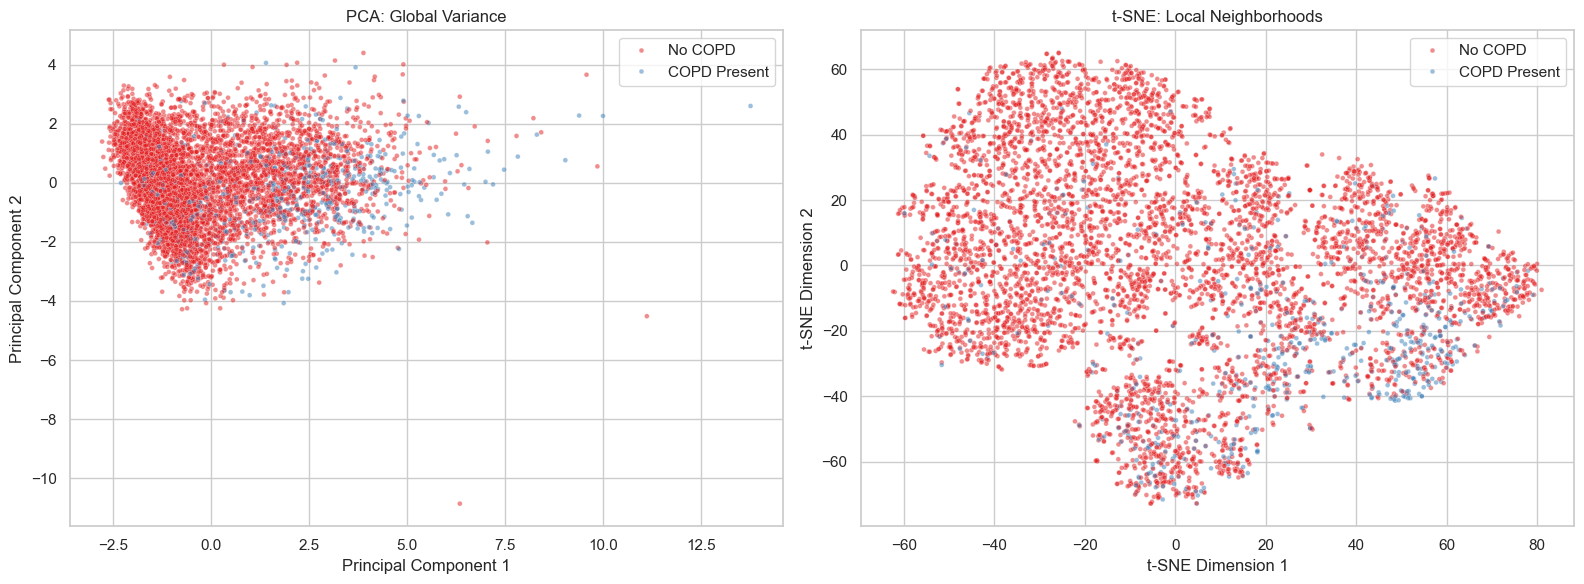

In [45]:
# PCA (Principal Component Analysis) — fitted on everyone, plotted on the sample
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_all = pca.fit_transform(X_unsup_scaled)
pca_result = pca_all[sample_idx]
print(f"Variance explained by PC1 + PC2: {pca.explained_variance_ratio_.sum():.1%}")

# t-SNE (T-distributed Stochastic Neighbor Embedding)
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init='pca', learning_rate='auto')
tsne_result = tsne.fit_transform(X_sample_unsup)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
labels = labels_all[sample_idx]

sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=labels, palette='Set1', ax=ax[0], alpha=0.5, s=12)
ax[0].set_title('PCA: Global Variance')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=labels, palette='Set1', ax=ax[1], alpha=0.5, s=12)
ax[1].set_title('t-SNE: Local Neighborhoods')
ax[1].set_xlabel('t-SNE Dimension 1')
ax[1].set_ylabel('t-SNE Dimension 2')

plt.tight_layout()
save_figure("pca_tsne_analysis.png")
plt.show()

* **PC1 + PC2 explain only 31.3 %** of the variance in the 17 numeric features, so there is no simple low-dimensional structure.
* COPD cases (blue) lean toward the **right along PC1**, the direction of smoking dose and cotinine, but overlap the non-COPD cloud heavily.
* **t-SNE** shows a few denser COPD regions (bottom and lower right, mostly smokers), yet no separate COPD cluster. Unsupervised structure alone cannot identify patients, which is consistent with the modest supervised PR-AUC.

### Density and Probabilistic Clustering (DBSCAN & GMM)
DBSCAN (density-based) and a Gaussian Mixture Model (probabilistic) show how the data separates under assumptions other than standard distance-based clustering.

* **DBSCAN:** Finds clusters by data density without a pre-set number of groups. It is useful for isolating "outlier" patients with unusual clinical profiles, which distance-based algorithms like K-Means would force into a group.

* **Gaussian Mixture Model (GMM):** Clinical measurements often have overlapping distributions (e.g., borderline eosinophil counts or BMI). GMM gives each patient a *probability* of belonging to each group, so boundaries between healthy and at-risk profiles are soft rather than hard cutoffs.

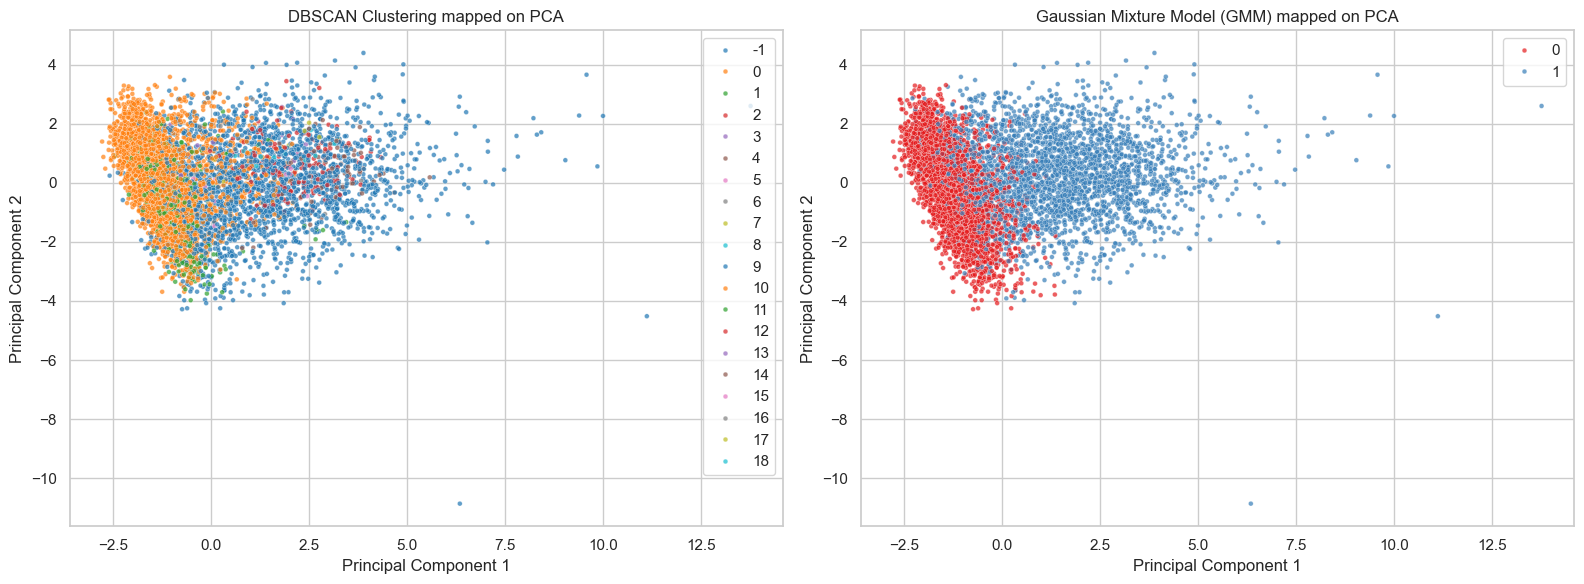

In [46]:
# eps and min_samples might need tuning depending on dataset density
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_sample_unsup)

# Gaussian Mixture Model (GMM) — we assume 2 components (healthy vs COPD-like profiles)
gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE)
gmm_clusters = gmm.fit(X_unsup_scaled).predict(X_sample_unsup)

# Visualize the clusters using the PCA components derived earlier
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN Plot (-1 indicates noise/outliers)
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=dbscan_clusters, palette='tab10', ax=ax[0], alpha=0.7, s=12)
ax[0].set_title('DBSCAN Clustering mapped on PCA')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

# GMM Plot
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=gmm_clusters, palette='Set1', ax=ax[1], alpha=0.7, s=12)
ax[1].set_title('Gaussian Mixture Model (GMM) mapped on PCA')
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')

plt.tight_layout()
save_figure("dbscan_gmm_analysis.png")
plt.show()

* **DBSCAN** finds one large core cluster, 18 tiny ones and a broad band of noise points (−1) on the right: silhouette **−0.17**, i.e. no real density structure.
* **GMM with 2 components** splits the population along PC1 (left vs right, roughly non-smokers vs smokers), but with a weak silhouette of **0.12**.
* Neither method finds a "COPD cluster". Patients form a continuum, not distinct groups.

In [47]:
from sklearn.metrics import silhouette_score

print("--- Unsupervised Model Silhouette Scores (6,000-patient sample) ---")

# DBSCAN Silhouette Score — requires at least 2 clusters
if len(set(dbscan_clusters)) > 1:
    dbscan_score = silhouette_score(X_sample_unsup, dbscan_clusters)
    print(f"DBSCAN Silhouette Score: {dbscan_score:.4f}")
else:
    print("DBSCAN Silhouette Score: N/A (Only one cluster found)")

# GMM Silhouette Score
gmm_score = silhouette_score(X_sample_unsup, gmm_clusters)
print(f"GMM Silhouette Score: {gmm_score:.4f}")

--- Unsupervised Model Silhouette Scores (6,000-patient sample) ---


DBSCAN Silhouette Score: -0.1716


GMM Silhouette Score: 0.1159


# KMeans Clustering

### Find Best Cluster Point

Finished k=2 | Score: 0.2121


Finished k=3 | Score: 0.2093


Finished k=4 | Score: 0.1126


Finished k=5 | Score: 0.1253


Finished k=6 | Score: 0.1159


Finished k=7 | Score: 0.1180


Finished k=8 | Score: 0.0903


Finished k=9 | Score: 0.0920


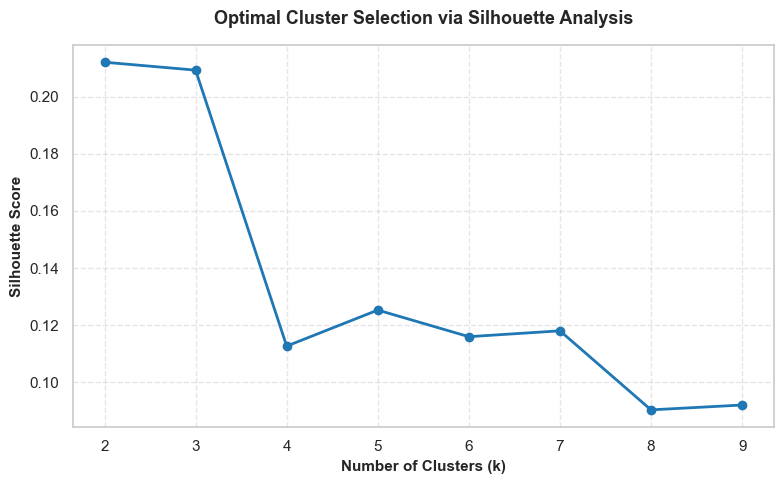

In [48]:
scores = []
for n in range(2, 10):
    km = KMeans(n_clusters=n, random_state=RANDOM_STATE, n_init=20)
    cluster_labels = km.fit_predict(X_sample_unsup)
    score = silhouette_score(X_sample_unsup, cluster_labels)
    scores.append(score)
    print(f"Finished k={n} | Score: {score:.4f}")

cluster_range = range(2, 10)
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, scores, marker='o', linewidth=2, color='#1f77b4', markersize=6)
plt.xlabel("Number of Clusters (k)", fontsize=11, fontweight='bold')
plt.ylabel("Silhouette Score", fontsize=11, fontweight='bold')
plt.title("Optimal Cluster Selection via Silhouette Analysis", fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### KMeans Clustering

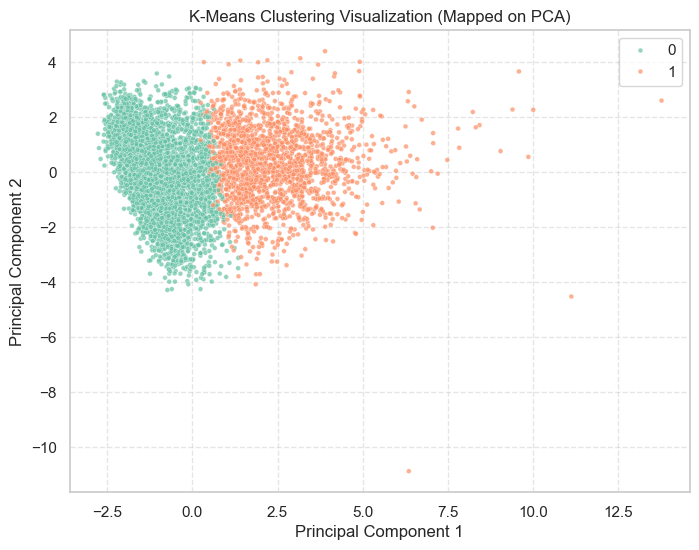

In [49]:
# Run K-Means (Using 2 clusters to see if it separates healthy vs COPD natively)
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans_clusters = kmeans.fit_predict(X_unsup_scaled)

# Create a copy of the dataframe to store results without warnings
lung_data_clustered = add_custom_features(lung_data)
lung_data_clustered["Cluster"] = kmeans_clusters

plt.figure(figsize=(8, 6))
# We plot using the PCA components derived earlier for a true 2D structural view
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=kmeans_clusters[sample_idx], palette="Set2", alpha=0.7, s=12)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Visualization (Mapped on PCA)")
plt.grid(True, linestyle="--", alpha=0.5)
save_figure("kmeans_clustering.png")
plt.show()

### Cluster Profile

In [50]:
# Look at the average values of the clinical features for each cluster (with the COPD rate)
profile_cols = numerical_features + ['copd_present']
cluster_profiles = lung_data_clustered.groupby("Cluster")[profile_cols].mean()
cluster_profiles.loc[:, 'patients'] = lung_data_clustered['Cluster'].value_counts().sort_index()

# Transpose for easier reading
print("--- Clinical Profile of Each Cluster ---")
display(cluster_profiles.T.round(3))

--- Clinical Profile of Each Cluster ---


Cluster,0,1
age,59.492,60.595
education_level,3.473,3.001
poverty_income_ratio,2.827,2.036
bmi,29.808,29.164
height_cm,164.934,168.989
cigarettes_per_day,2.324,18.486
smoking_years,3.810,35.607
household_smokers,0.098,0.762
general_health,2.774,3.241
eosinophils,0.195,0.233


* The silhouette search favours **k = 2 (0.212)**, barely ahead of k = 3 (0.209); all scores are weak.
* **The two K-Means clusters are smokers vs non-smokers.** Cluster 1 (7,242 adults) averages **31 pack-years** vs 1.6, 18.5 vs 2.3 cigarettes/day, log-cotinine +1.07 vs −1.39, and 0.76 vs 0.10 household smokers. It is also poorer (poverty ratio 2.04 vs 2.83), less educated, in worse self-rated health (3.24 vs 2.77) and has a higher neutrophil-to-lymphocyte ratio.
* **COPD rate: 20.4 % in the smoker cluster vs 5.5 %**, a 3.7× difference. Unsupervised learning rediscovers tobacco exposure as the dominant risk axis, but four in five members of the high-risk cluster still do not have diagnosed COPD.

# Anomaly Detection
DBSCAN finds noisy points only as a side effect; anomaly detectors are built specifically to find extreme clinical anomalies (patients with highly unusual feature combinations).

* **One-Class SVM:** Learns a soft boundary around the majority of the data without assuming a specific distribution.

* **Elliptic Envelope:** Assumes the data is roughly Gaussian (normally distributed) and draws an elliptical boundary from the data's variance.

* **Isolation Forest:** Isolates points by randomly selecting and splitting features; anomalies need fewer splits to isolate.

* **ECOD:** Flags outliers from the empirical cumulative distribution of each dimension, with no parameters to tune.

* **COPOD:** Models the joint distribution with copulas and flags points in the low-probability tails.

* **Autoencoder:** A neural network that learns to compress and reconstruct normal data; anomalies have high reconstruction errors.

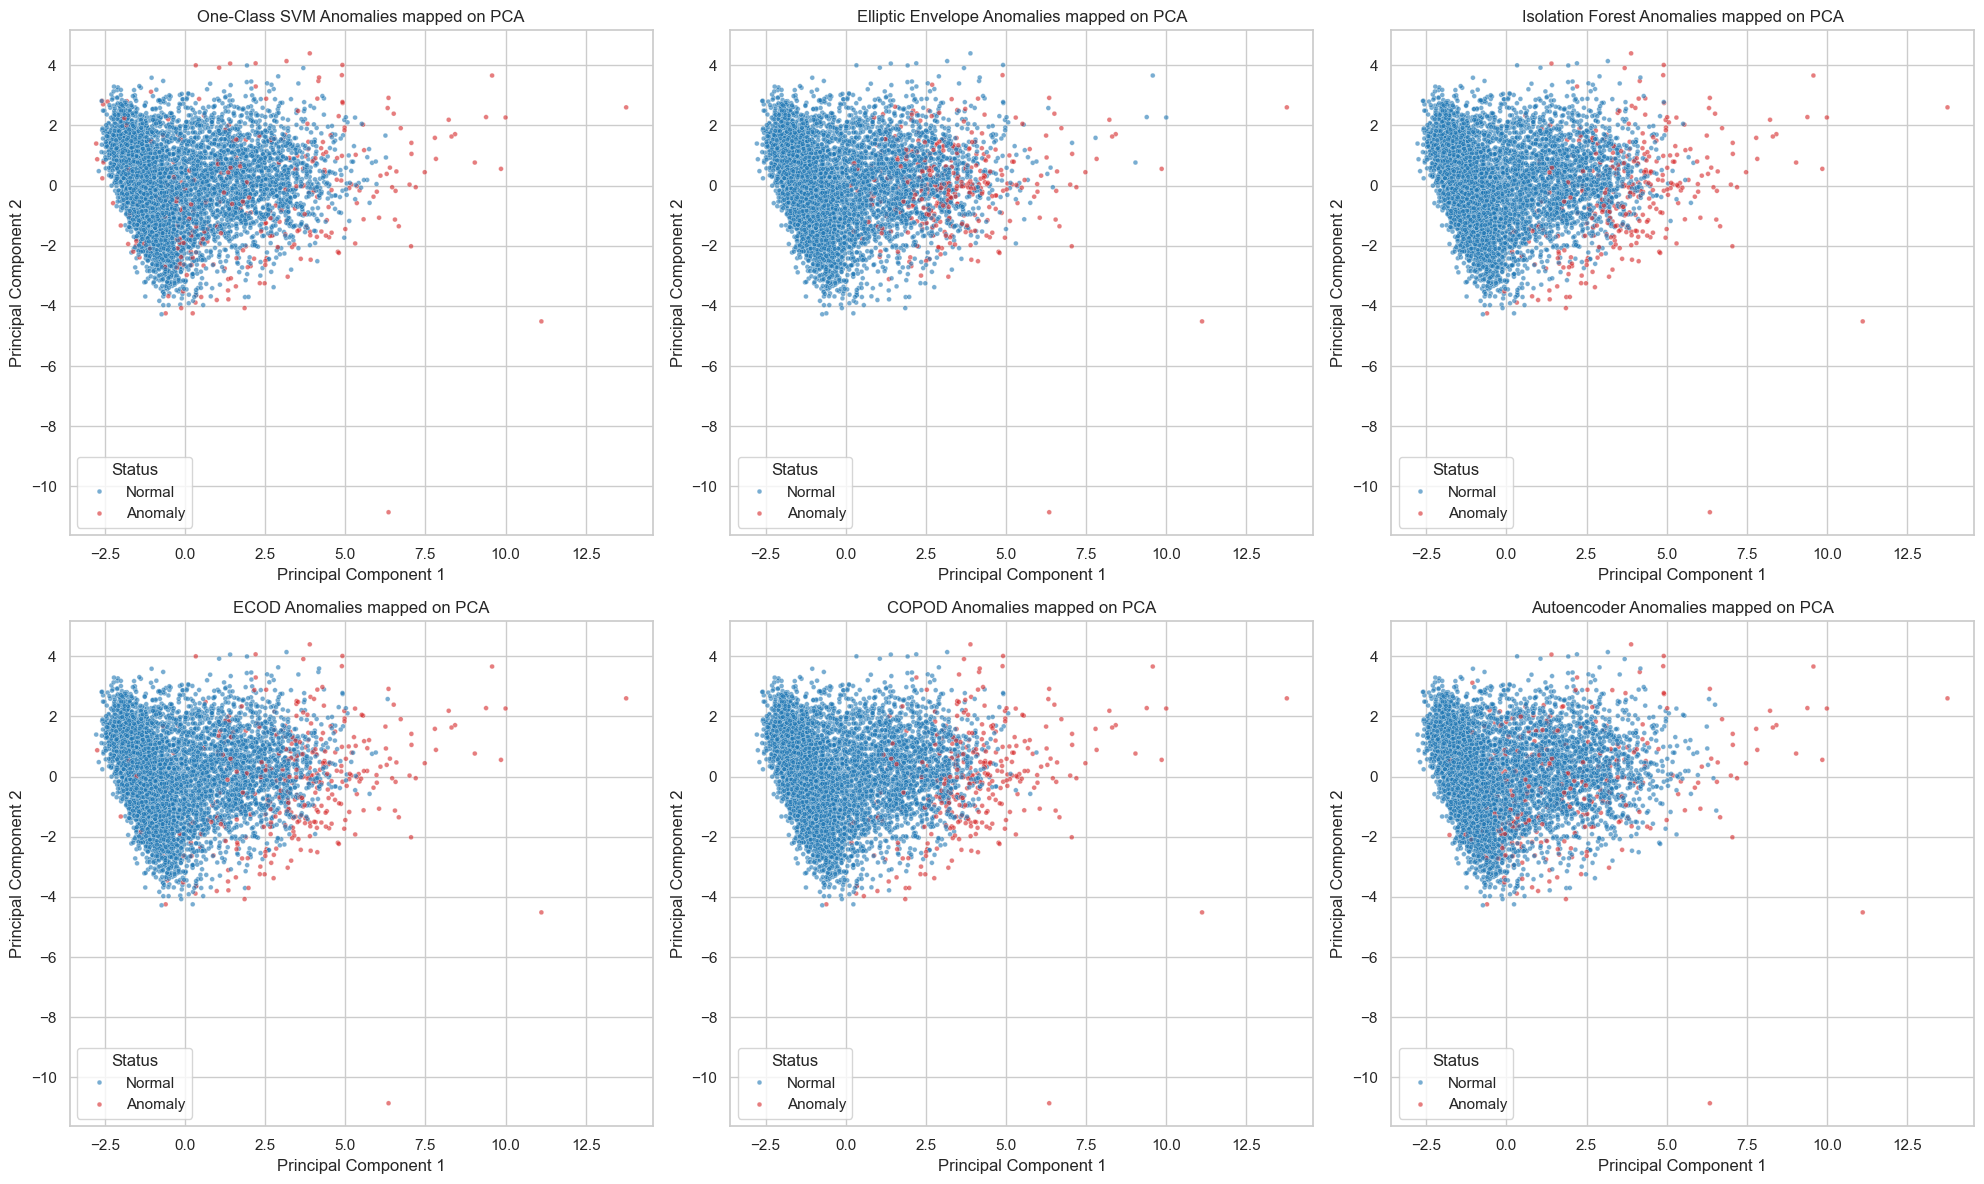

In [51]:
# On Colab: !pip install -q pyod
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.auto_encoder import AutoEncoder

# We will assume around 5% of our patient records might be extreme clinical anomalies (contamination / nu)
anomaly_fraction = 0.05

# One-Class SVM
oc_svm = OneClassSVM(nu=anomaly_fraction, kernel="rbf", gamma="scale")
svm_anomalies = oc_svm.fit_predict(X_unsup_scaled)  # Returns -1 for anomalies, 1 for normal

# Elliptic Envelope
elliptic = EllipticEnvelope(contamination=anomaly_fraction, random_state=RANDOM_STATE)
ee_anomalies = elliptic.fit_predict(X_unsup_scaled)

# Isolation Forest
iso_forest = IsolationForest(contamination=anomaly_fraction, random_state=RANDOM_STATE)
if_anomalies = iso_forest.fit_predict(X_unsup_scaled)

# ECOD — PyOD returns 1 for anomaly, 0 for normal. Mapping to -1 and 1 for consistency.
ecod = ECOD(contamination=anomaly_fraction)
ecod.fit(X_unsup_scaled)
ecod_anomalies = np.where(ecod.labels_ == 1, -1, 1)

# COPOD
copod = COPOD(contamination=anomaly_fraction)
copod.fit(X_unsup_scaled)
copod_anomalies = np.where(copod.labels_ == 1, -1, 1)

# Autoencoder
with silenced():
    ae = AutoEncoder(contamination=anomaly_fraction, random_state=RANDOM_STATE, verbose=0)
    ae.fit(X_unsup_scaled)
ae_anomalies = np.where(ae.labels_ == 1, -1, 1)

models_results = [
    ('One-Class SVM', svm_anomalies),
    ('Elliptic Envelope', ee_anomalies),
    ('Isolation Forest', if_anomalies),
    ('ECOD', ecod_anomalies),
    ('COPOD', copod_anomalies),
    ('Autoencoder', ae_anomalies)
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
ax = axes.flatten()
for i, (title, anomalies) in enumerate(models_results):
    status = np.where(anomalies[sample_idx] == -1, 'Anomaly', 'Normal')
    sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=status, hue_order=['Normal', 'Anomaly'],
                    palette={'Normal': '#1f77b4', 'Anomaly': '#d62728'}, ax=ax[i], alpha=0.6, s=12)
    ax[i].set_title(f'{title} Anomalies mapped on PCA')
    ax[i].set_xlabel('Principal Component 1')
    ax[i].set_ylabel('Principal Component 2')
    ax[i].legend(title='Status')

plt.tight_layout()
save_figure("anomaly_detection_models.png")
plt.show()

* Each detector flags **5 %** of the population, the contamination rate it was given. All of them place their anomalies on the **right of the PCA plot**: heavy smokers, extreme cotinine, unusual blood counts.
* **COPD rate among the anomalies is 26–39 %**, against 9.9 % overall. It is highest for the **Isolation Forest (39.3 %)**, then COPOD (37.1 %) and ECOD (36.6 %).
* In this data, "unusual" largely means "sicker". That matters for the Stage 1 gate below.

In [52]:
anomaly_counts = []
copd_flags = lung_data['copd_present'].values == 1

for title, anomalies in models_results:
    anomaly_count = (anomalies == -1).sum()
    anomaly_counts.append({
        'Model': title,
        'Anomalies Detected': anomaly_count,
        'Normal Patients': (anomalies == 1).sum(),
        'Anomaly %': f"{anomaly_count / len(anomalies) * 100:.2f}%",
        'COPD rate among anomalies': f"{copd_flags[anomalies == -1].mean() * 100:.1f}%"
    })

df_anomaly_comp = pd.DataFrame(anomaly_counts).set_index('Model')
print("=== Anomaly Detection Counts ===")
display(df_anomaly_comp)

# --- Consensus Calculation ---
all_anomalies = np.vstack([anomalies for _, anomalies in models_results])
times_flagged = (all_anomalies == -1).sum(axis=0)

print("\n=== Anomaly Consensus ===")
print(f"Patients flagged by at least 1 model: {(times_flagged >= 1).sum()}")
print(f"Patients flagged by majority (>= 3 models): {(times_flagged >= 3).sum()}")
print(f"Patients flagged by ALL 6 models (Strict Consensus): {(times_flagged == 6).sum()}")
print(f"\nOverall COPD prevalence: {copd_flags.mean():.1%} | among strict-consensus anomalies: {copd_flags[times_flagged == 6].mean():.1%}")

=== Anomaly Detection Counts ===


,Anomalies Detected,Normal Patients,Anomaly %,COPD rate among anomalies
Model,,,,
One-Class SVM,1228,23294,5.01%,27.6%
Elliptic Envelope,1227,23295,5.00%,30.1%
Isolation Forest,1227,23295,5.00%,39.3%
ECOD,1227,23295,5.00%,36.6%
COPOD,1227,23295,5.00%,37.1%
Autoencoder,1227,23295,5.00%,26.1%



=== Anomaly Consensus ===
Patients flagged by at least 1 model: 3192
Patients flagged by majority (>= 3 models): 1142
Patients flagged by ALL 6 models (Strict Consensus): 133

Overall COPD prevalence: 9.9% | among strict-consensus anomalies: 48.9%


* **3,192** adults are flagged by at least one detector, **1,142** by a majority (≥ 3) and **133** by all six.
* **48.9 % of the strict-consensus anomalies have COPD**, five times the population rate. The most extreme profiles are the ones most likely to be diseased.

# Cascade Architecture

### Lung Disease (COPD) Cascade Architecture

The cascade maximizes clinical safety and model reliability:

1. **Stage 1 (Anomaly Gate):** An **Isolation Forest** flags patients with implausible or extreme profiles (data-entry errors, rare compounding conditions). They go to manual review instead of receiving a prediction. Two changes from the kidney notebook: the gate is fitted on the **training set only**, and its contamination is **1 %** rather than 5 %, because the anomaly analysis above shows that much of what a wider gate removes is disease itself. The check below measures how often COPD and non-COPD patients are withheld.
2. **Stage 2 (Supervised Classification):** Patients who pass Stage 1 are scored by the **calibrated best model**. The out-of-fold cost-optimal threshold decides "refer for spirometry", and risk bands are anchored to it: **Low** (below the threshold), **Medium** (threshold to 50 %), **High** (≥ 50 %).

In [53]:
# Stage 1 gate: numeric features only, fitted on the TRAINING set
anomaly_gate = Pipeline(steps=[
    ('engineering', FunctionTransformer(add_custom_features)),
    ('select', ColumnTransformer([('numeric', 'passthrough', numerical_features)])),
    ('scaler', RobustScaler()),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('detector', IsolationForest(n_estimators=200, contamination=0.01, random_state=RANDOM_STATE))
])
anomaly_gate.fit(X_train)

gate_flags = anomaly_gate.predict(X_test) == -1
print(f"Test patients withheld by the gate: {gate_flags.sum()} ({gate_flags.mean():.2%})")
print(f"  among COPD patients   : {gate_flags[y_test.values == 1].mean():.2%}")
print(f"  among non-COPD        : {gate_flags[y_test.values == 0].mean():.2%}")

Test patients withheld by the gate: 58 (1.18%)
  among COPD patients   : 6.17%
  among non-COPD        : 0.63%


* The gate (Isolation Forest, 1 % contamination, fitted on the training set only) withholds **58 of 4,905** test patients (1.18 %).
* **It withholds COPD patients ten times as often: 6.17 % of COPD patients (30 of 486) vs 0.63 % of the rest.** That is the anomaly finding above in action.
* Withheld patients are **sent to manual clinical review, not discarded**. For a screening tool that is the safe direction: a very unusual profile reaches a clinician instead of an automated "routine care". It does mean about 6 % of true cases bypass the model, so review capacity has to be planned for them.

In [54]:
# SHAP explainer for patient-level explanations (same model type logic as above)
cascade_explainer = build_shap_explainer(model_object, background)

def describe_feature(feature, raw_row):
    # "Feature = this patient's value": one-hot columns are mapped back to the original answer,
    # numeric columns show the unscaled value (the model itself sees them scaled)
    for cat in categorical_features:
        if feature.startswith(cat + '_'):
            return f"{cat.replace('_', ' ').title()} = {raw_row[cat]}"
    value = raw_row.get(feature, np.nan)
    shown = f"{value:.3g}" if pd.notna(value) else "missing (imputed)"
    return f"{feature.replace('_', ' ').title()} = {shown}"

def lung_evaluation(patients_data, model=calibrated_clf, anomaly_model=anomaly_gate, threshold=best_threshold,
                    patient_names=None, explain=True):
    # --- STAGE 1: Anomaly Detection ---
    anomalies = anomaly_model.predict(patients_data) if anomaly_model is not None else None

    # Let the AI calculate its calibrated COPD probability (%)
    prediction_probabilities = model.predict_proba(patients_data)[:, 1]

    # If explanations are requested, prepare SHAP components
    if explain:
        X_processed = preprocessor.transform(patients_data)
        patient_shap = compute_shap(cascade_explainer, X_processed)
        raw_rows = add_custom_features(patients_data)     # unscaled values for readable explanations

    for i in range(len(patients_data)):
        name = patient_names[i] if patient_names else f"Patient {i+1}"
        print(f"=== Diagnostic Results for {name} ===")

        # --- STAGE 1 CHECK ---
        if anomalies is not None and anomalies[i] == -1:
            print("🚨 STAGE 1 CASCADE REJECTION: Extreme Clinical Anomaly Detected!")
            print("Action: Prediction withheld. Patient requires manual clinical review due to implausible or highly unusual feature combinations.\n")
            continue # Skip Stage 2 entirely

        # --- STAGE 2: CLASSIFICATION ---
        p = prediction_probabilities[i]

        # Risk stratification anchored to the cost-optimal threshold
        if p < threshold:
            risk_level = "Low Risk"
        elif p < 0.50:
            risk_level = "Medium Risk"
        else:
            risk_level = "High Risk"

        print(f"COPD Probability     : {p * 100:.2f}%")
        print(f"Risk Categorization  : {risk_level}")
        print(f"Recommendation       : {'Refer for spirometry' if p >= threshold else 'Routine care'}")

        if explain:          # Add Text-based SHAP Explanations
            print("\nExplanation:")
            explanation = shap.Explanation(
                values=patient_shap.values[i],
                base_values=np.ravel(patient_shap.base_values)[i] if np.ndim(patient_shap.base_values) else patient_shap.base_values,
                data=X_processed[i],
                feature_names=feature_names
            )

            # Sort features by absolute SHAP value to find top contributors
            sorted_indices = np.argsort(np.abs(explanation.values))[::-1]
            print("Top Contributing Factors:")
            for rank, idx in enumerate(sorted_indices[:4]):
                print(f"{rank+1}. {describe_feature(feature_names[idx], raw_rows.iloc[i])} ({explanation.values[idx]:+.2f})")

            # Generate and display Waterfall Plot
            print(f"\nWaterfall Plot for {name}:")
            plt.figure(figsize=(8, 6), dpi=100)
            shap.plots.waterfall(explanation, max_display=10, show=False)
            plt.title(f'SHAP Waterfall Plot for {name}', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
        print("\n" + "="*50 + "\n")

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


We enhanced the cascade architecture by embedding SHAP (SHapley Additive exPlanations) directly into the evaluation function.

# AI Prediction Test

=== Diagnostic Results for Patient A (Index 8021, true label: No COPD) ===
COPD Probability     : 6.09%
Risk Categorization  : Low Risk
Recommendation       : Routine care

Explanation:
Top Contributing Factors:
1. Sob On Exertion = No (-0.35)
2. General Health = 4 (+0.32)
3. Ethnicity = Non-Hispanic White (+0.30)
4. Age = 73 (+0.23)

Waterfall Plot for Patient A (Index 8021, true label: No COPD):


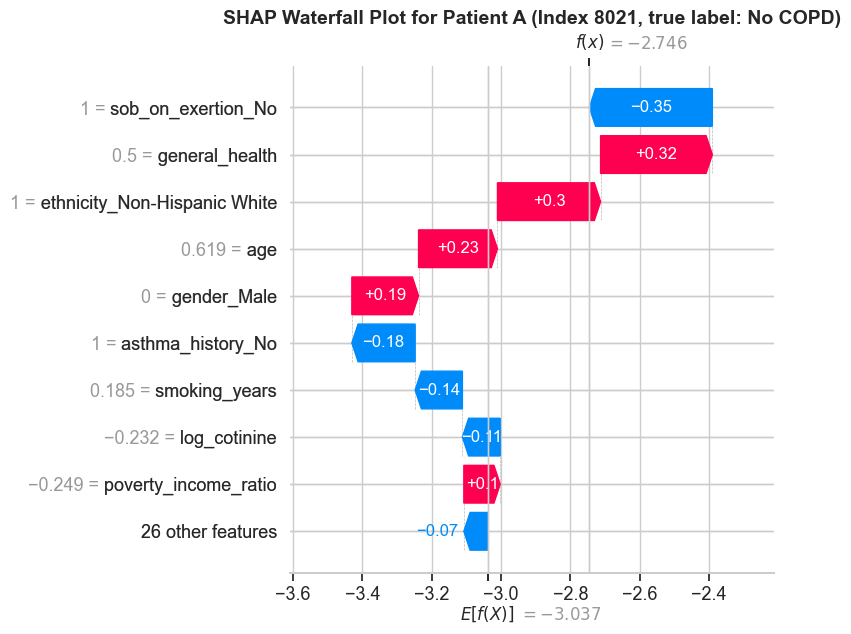



=== Diagnostic Results for Patient B (Index 5551, true label: No COPD) ===
COPD Probability     : 3.46%
Risk Categorization  : Low Risk
Recommendation       : Routine care

Explanation:
Top Contributing Factors:
1. Sob On Exertion = No (-0.35)
2. General Health = 4 (+0.32)
3. Ethnicity = Non-Hispanic White (+0.30)
4. Smoking Years = 0 (-0.23)

Waterfall Plot for Patient B (Index 5551, true label: No COPD):


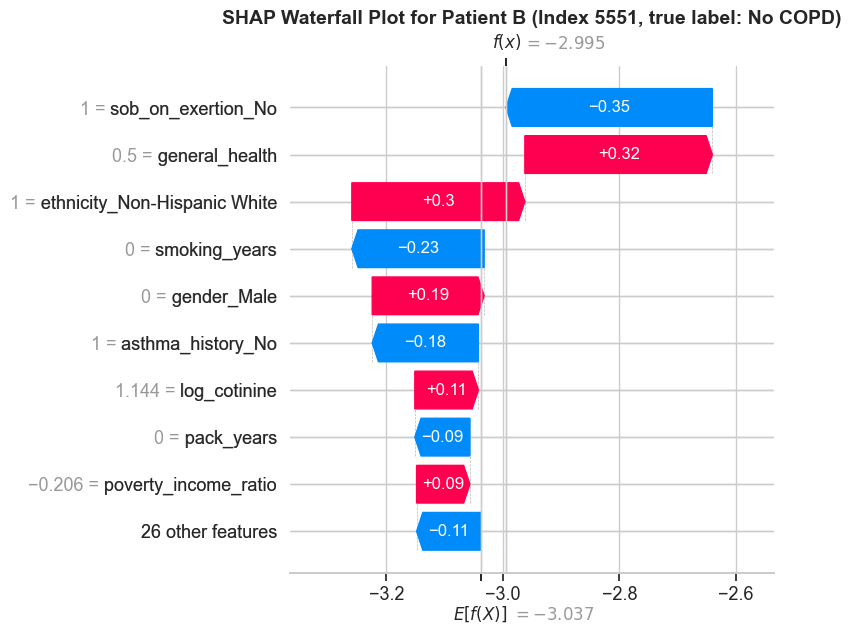



=== Diagnostic Results for Patient C (Index 7957, true label: No COPD) ===
COPD Probability     : 31.29%
Risk Categorization  : Medium Risk
Recommendation       : Refer for spirometry

Explanation:
Top Contributing Factors:
1. Asthma History = Yes (+1.48)
2. General Health = 5 (+0.60)
3. Smoking Years = 39 (+0.48)
4. Sob On Exertion = No (-0.35)

Waterfall Plot for Patient C (Index 7957, true label: No COPD):


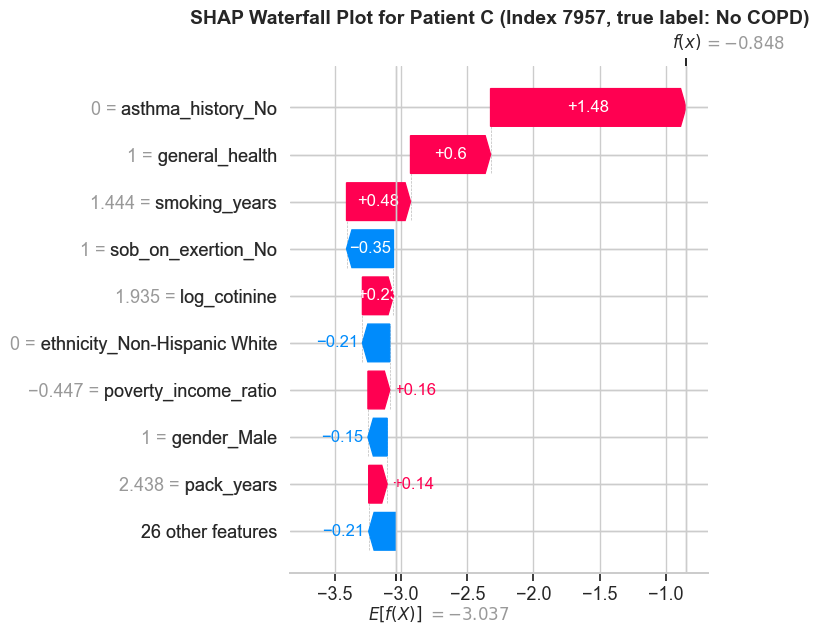

In [55]:
# Let's test the evaluation function on the first 3 patients in the test set
sample_patients = X_test.head(3)
sample_names = [f"Patient {chr(65 + i)} (Index {idx}, true label: {'COPD' if y_test.loc[idx] else 'No COPD'})"
                for i, idx in enumerate(sample_patients.index)]

lung_evaluation(sample_patients, patient_names=sample_names, explain=True)

# Save and Test Final Model (Joblib)
We save the calibrated model, the Stage 1 anomaly gate and a `metadata.json` (threshold, feature lists) to `models/`, then reload them and test with mock patients.

*Note:* the pipelines reference `add_custom_features`, defined in this notebook. Any script that loads them must define or import the same function; the module's `src/` package will do that.

In [56]:
model_filename = os.path.join(models_dir, "lung_copd_calibrated_model.joblib")
gate_filename = os.path.join(models_dir, "lung_copd_anomaly_gate.joblib")
metadata_filename = os.path.join(models_dir, "metadata.json")

joblib.dump(calibrated_clf, model_filename)
joblib.dump(anomaly_gate, gate_filename)

metadata = {
    'best_model': best_model_name,
    'selection_rule': 'one-standard-error rule on 5-fold CV PR-AUC',
    'optimal_threshold': best_threshold,
    'cost_weights': {'false_negative': FN_COST, 'false_positive': FP_COST},
    'risk_bands': {'low': f'< {best_threshold:.4f}', 'medium': f'{best_threshold:.4f} - 0.50', 'high': '>= 0.50'},
    'raw_input_columns': X.columns.tolist(),
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'test_metrics': {'roc_auc': roc_auc_score(y_test, calib_probas), 'pr_auc': average_precision_score(y_test, calib_probas),
                     'brier_score': brier_calibrated, 'recall_at_threshold': recall_score(y_test, sim_preds_best),
                     'precision_at_threshold': precision_score(y_test, sim_preds_best)},
    'bootstrap_confidence_intervals': confidence_intervals,
    'training_rows': len(X_train), 'test_rows': len(X_test), 'prevalence': float(y.mean())
}
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=2, default=float)

print(f"[SAVED] Calibrated Model -> {model_filename}")
print(f"[SAVED] Anomaly Gate     -> {gate_filename}")
print(f"[SAVED] Metadata         -> {metadata_filename}")

[SAVED] Calibrated Model -> E:\Disease-Risk-Prediction\lung\tabular\models\lung_copd_calibrated_model.joblib
[SAVED] Anomaly Gate     -> E:\Disease-Risk-Prediction\lung\tabular\models\lung_copd_anomaly_gate.joblib
[SAVED] Metadata         -> E:\Disease-Risk-Prediction\lung\tabular\models\metadata.json


[LOADED] Successfully loaded model from E:\Disease-Risk-Prediction\lung\tabular\models\lung_copd_calibrated_model.joblib

=== Loaded Joblib Model Test ===
=== Diagnostic Results for Patient A (High Risk Mock) ===
COPD Probability     : 88.72%
Risk Categorization  : High Risk
Recommendation       : Refer for spirometry

Explanation:
Top Contributing Factors:
1. Asthma History = Yes (+1.48)
2. Sob On Exertion = Yes (+0.69)
3. Smoking Years = 48 (+0.65)
4. Pack Years = 60 (+0.39)

Waterfall Plot for Patient A (High Risk Mock):


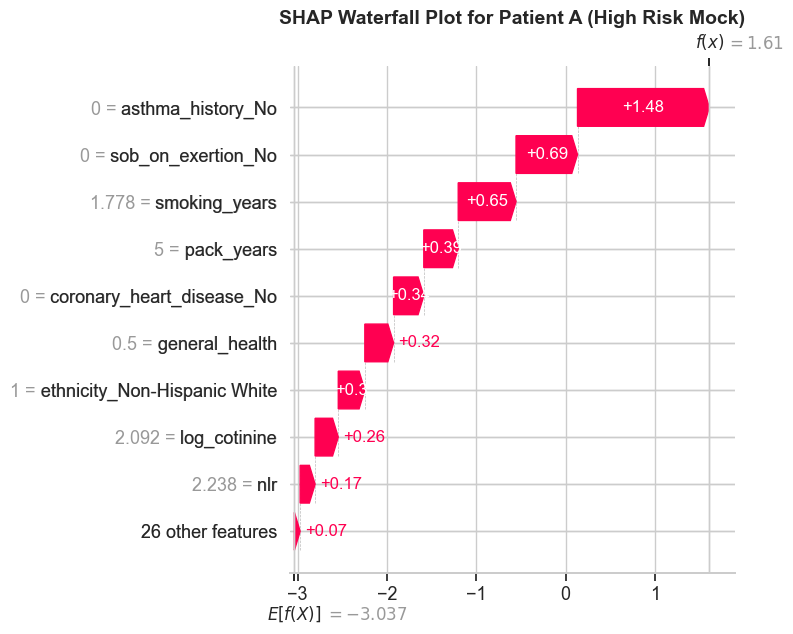



=== Diagnostic Results for Patient B (Low Risk Mock) ===
COPD Probability     : 0.54%
Risk Categorization  : Low Risk
Recommendation       : Routine care

Explanation:
Top Contributing Factors:
1. Sob On Exertion = No (-0.35)
2. Age = 45 (-0.26)
3. General Health = 2 (-0.24)
4. Smoking Years = 0 (-0.23)

Waterfall Plot for Patient B (Low Risk Mock):


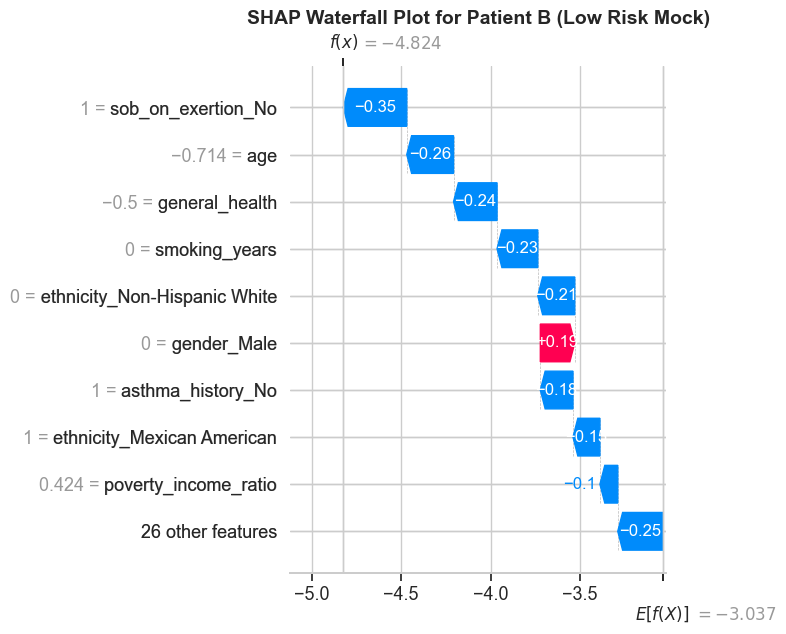



=== Diagnostic Results for Patient C (Extreme Anomaly Mock) ===
🚨 STAGE 1 CASCADE REJECTION: Extreme Clinical Anomaly Detected!
Action: Prediction withheld. Patient requires manual clinical review due to implausible or highly unusual feature combinations.



In [57]:
# Test with mock patients
loaded_model = joblib.load(model_filename)
loaded_gate = joblib.load(gate_filename)
print(f"[LOADED] Successfully loaded model from {model_filename}\n")

mock_patients = pd.DataFrame([
    {
        # Patient A (High Risk Mock: long-term heavy smoker, asthma, breathless, fair health)
        "age": 68.0, "gender": "Male", "ethnicity": "Non-Hispanic White", "education_level": 2.0, "poverty_income_ratio": 1.1,
        "bmi": 21.5, "height_cm": 175.0, "smoking_status": "Current", "cigarettes_per_day": 25.0, "smoking_years": 48.0,
        "household_smokers": 1.0, "serum_cotinine": 350.0, "asthma_history": "Yes", "heart_failure": "No",
        "coronary_heart_disease": "Yes", "sob_on_exertion": "Yes", "general_health": 4.0,
        "eosinophils": 0.4, "neutrophils": 6.5, "lymphocytes": 1.4, "hemoglobin": 16.2
    },
    {
        # Patient B (Low Risk Mock: 45-year-old never-smoker, no symptoms, normal labs)
        "age": 45.0, "gender": "Female", "ethnicity": "Mexican American", "education_level": 4.0, "poverty_income_ratio": 3.5,
        "bmi": 26.0, "height_cm": 160.0, "smoking_status": "Never", "cigarettes_per_day": 0.0, "smoking_years": 0.0,
        "household_smokers": 0.0, "serum_cotinine": 0.015, "asthma_history": "No", "heart_failure": "No",
        "coronary_heart_disease": "No", "sob_on_exertion": "No", "general_health": 2.0,
        "eosinophils": 0.15, "neutrophils": 3.5, "lymphocytes": 2.2, "hemoglobin": 13.5
    },
    {
        # Patient C (Extreme Anomaly Mock: Impossible values to trigger Stage 1 Rejection)
        "age": 150.0, "gender": "Male", "ethnicity": "Other Hispanic", "education_level": 1.0, "poverty_income_ratio": 0.1,
        "bmi": 95.0, "height_cm": 250.0, "smoking_status": "Current", "cigarettes_per_day": 300.0, "smoking_years": 140.0,
        "household_smokers": 2.0, "serum_cotinine": 20000.0, "asthma_history": "Yes", "heart_failure": "Yes",
        "coronary_heart_disease": "Yes", "sob_on_exertion": "Yes", "general_health": 5.0,
        "eosinophils": 9.0, "neutrophils": 90.0, "lymphocytes": 0.2, "hemoglobin": 25.0
    }
])[X.columns]

print("=== Loaded Joblib Model Test ===")
lung_evaluation(
    patients_data=mock_patients,
    model=loaded_model,
    anomaly_model=loaded_gate,
    patient_names=["Patient A (High Risk Mock)", "Patient B (Low Risk Mock)", "Patient C (Extreme Anomaly Mock)"]
)

# Conclusion
This notebook built and evaluated a calibrated, explainable, cascade-gated COPD risk screen on **24,522 adults aged 40+ from six NHANES cycles (2007–2020)**, using only questionnaire answers, body measurements and a routine blood count.

**Key Results:**
* **17 models compared on 5-fold CV PR-AUC**, from logistic regression to TabPFN, TabM, FT-Transformer and a stacking ensemble. The top eight are within one standard error of each other (CV PR-AUC 0.453–0.466): the information in the inputs, not the model family, sets the ceiling.
* **Logistic Regression was selected** by the one-standard-error rule: **test ROC-AUC 0.864 (95 % CI 0.847–0.880)** and **PR-AUC 0.482 (0.434–0.527)**, about five times the 0.10 of a random ranking. Its probabilities are well calibrated already (Brier 0.066 vs 0.089 baseline).
* **Cost-based threshold 0.164** (a missed case = 5 false alarms), chosen on out-of-fold training predictions: on the untouched test set it catches **69 % of COPD patients (CI 65–73 %)** with **86 % specificity**, at about 1.9 false alarms per case found.
* **Drivers:** asthma history, shortness of breath on exertion, years of smoking and self-rated health carry almost all the signal. Blood counts add next to nothing, so a short questionnaire is enough for screening.
* **Unsupervised view:** there is no natural COPD cluster. K-Means splits smokers from non-smokers (20 % vs 5.5 % COPD), and anomaly detectors find a small, much sicker tail (49 % COPD among consensus anomalies).
* **Cascade:** a Stage 1 Isolation Forest gate routes 1.2 % of patients, 6 % of the true cases among them, to manual review. Stage 2 gives a calibrated probability, Low / Medium / High risk bands anchored at the threshold, and a per-patient SHAP explanation.

**Limitations:**
* **Self-reported diagnosis:** the label is "ever told by a doctor". COPD is widely under-diagnosed, so some "No COPD" adults have the disease, which caps achievable precision. The model learns *diagnosed* COPD.
* **Label drift:** the 2017–2020 questionnaire merged three questions into one, which raised measured prevalence.
* **Population-level patterns:** ethnicity, sex and income act partly as proxies for access to diagnosis, not just disease risk.
* **No spirometry:** lung-function tests exist in NHANES only for 2007–2012 and were left out to avoid cycle-shaped gaps. They would be the obvious way to build a stronger, objective label.
* Survey weights are not applied: the metrics describe this sample, not the U.S. population.

**Future Work:**
* Re-train on the **2007–2012 spirometry subset** with an objective COPD label (FEV1/FVC < 0.70) and compare it with the self-report model.
* External validation on a non-NHANES cohort.
* Use this screen as **Stage 0 of the lung cascade**: a positive result routes the patient to the chest X-ray model (`models/lung/image_based`) when an image is available.